# LIBRARY COMPARISON
Let's have a competition between three popular gradient boosting libraries. We will contest in solving the regression problem. We will select the winner based on the following criteria:
- prediction accuracy
- speed
- ease of use of the library

# TABLE OF CONTENTS <a class="anchor" id="0.1"></a>
- 1 [Сomparison table](#1)
- 2 [Setup](#2)
- 3 [Install libraries](#3)
- 4 [Import data](#4)
- 5 [Data first look](#5)
- 6 [First round](#6)
    - 6.1 [LightGBM](#6.1)
    - 6.2 [XGBoost](#6.2)
    - 6.3 [CatBoost](#6.3)
- 7 [First round conclusions](#7)
- 8 [Second round](#8)
    - 8.1 [EDA](#8.1)
    - 8.2 [Filling missing values](#8.2)
    - 8.3 [Feature engeeniring](#8.3)
- 9 [Data preprocessing](#9)
- 10 [Modeling](#10)
    - 10.1 [LightGBM](#10.1)
        - 10.1.1 [Sklearn interface LGBMRegressor()](#10.1.1)
        - 10.1.2 [Core training API](#10.1.2)
        - 10.1.3 [Optuna](#10.1.3)
        - 10.1.4 [LightGBM Tuner](#10.1.4)
    - 10.2 [XGBoost](#10.2)
        - 10.2.1 [Default hyperparameters](#10.2.1)
        - 10.2.2 [Optuna](#10.2.2)
    - 10.3 [CatBoost](#10.3)
        - 10.3.1 [Built-in encoder](#10.3.1)
        - 10.3.2 [Third party encoding](#10.3.2)
        - 10.3.3 [Optuna](#10.3.3)
- 11 [Conclusions](#11)
- 12 [Winner](#12)

# COMPARISON TABLE <a class="anchor" id="1"></a>
[Table of Contents](#0.1)

But before we get started, let's take a look at how CatBoost, XGBoost and LightGBM are similar and how they differ.

<table>
    <tr>
        <td width='10%'></td>
        <td width='30%'><b>LightGBM</b></td>
        <td width='30%'><b>XGBoost</b></td>
        <td width='30%'><b>CatBoost</b></td>
    </tr>
    <tr>
        <td><b>Working principle</b></td>
        <td>Leaf wise tree growth. The algorithm at each step chooses to divide the nodes with the best score. Because of this, trees can be asymmetrical.</td>
        <td>Level wise tree growth. The algorithm builds the tree level by level until the max tree depth is reached.</td>
        <td>Layer wise boosting. The algorithm builds the tree with the same predictors at the nodes of the same level.</td>
    </tr>
    <tr>
        <td><b>Key features</b></td>
        <td>GOSS (Gradient based one side sampling) Why train from observations with minimal error? Let's better train from observations with max error. The algorithm uses all observations with a max error and a small part with a min error for training.

Advantage: increase the speed

Disadvantage: the distribution of observations is disturbed.</td>
        <td>The tree builds sequentially level by level, and then leaves are pruning with gain below the threshold (gamma, min_split_loss).

The tree builds faster, there is no need to check every leaf. Pruning the leaves avoids overfitting.</td>
        <td>CatBoost builds symmetrical trees. In first, algorithm selecte the parameters that better divide the observations. Than, CatBoost  builds the tree according to the already selected parameters.

Training and prediction run on different samples at each iteration. (samples are generate by permutation or bootstrap).

Ordered boosting. Catboost sort observations by date. The predictions for next observation is calculated on the observations with the lowest serial number in the leaf (GBM use mean in leaf).</td>
    </tr>
    <tr>
        <td><b>Stopping criteria</b></td>
        <td>Max leaves, max tree depth. Node partitioning: min split gain, min child weight, min child samples</td>
        <td>Max tree depth, max leaves. Pruning: min child weight, gamma</td>
        <td>Depth, max leaves</td>
    </tr>
    <tr>
        <td><b>Step by step</b></td>
        <td>
            <ol>
<li>Use observation with a large gradient value (error)</li>
<li>Make an initial prediction</li>
<li>Calculate residuals</li>
<li>Build tree<br>
- Choose best split<br>
- Divide observations by leaves</li>
<li>Calculate the output values of leaves</li>
<li>Make new predictions</li>
 </ol>
</td>
<td>
    <ol>
 <li>Make an initial prediction</li>
 <li>Calculate residuals</li>
 <li>Build an XGBoost tree<br>
- Choose best split<br>
- Divide observations by leaves</li>
 <li>Prune the tree</li>
 <li>Calculate the output values of leaves<br>
OUTPUT = Σres / (Nres + λ)</li>
<li>Make new predictions<br>
PREDICT(i) = PREDICT(i-1) + ε × OUTPUT(i-1)</li>
        </ol>
</td>
<td>
    <ol>
 <li>Make an initial prediction</li>
 <li>Calculate residuals</li>
 <li>Find parameter which best divides the dataset. Find next parameter. Repeat until the number of parameters is equal to the depth of the tree.</li>
 <li>Build tree by pre-determined parameters<br>
Choose best split<br>
Divide observations by leaves</li>
 <li>Calculate the output values of leaves based on ordered residuals</li>
 <li>Make new predictions</li>
 <li>Choose new parameters to the next tree</li>
 </ol>
Observations in the leaf are sorted in chronological order. If there is no date, then the observations are assigned a serial number. Prediction for each next observation is calculated based on the previous observations.
</td>
    </tr>
    <tr>
        <td><b>Splitting</b></td>
        <td>
        <ol>
            <li>
                Information Gain is used with a correction coeff to find the best split<br>
K = (1-A) / B, where A — proportion of observations with a large error, B — with a small error</li>

 <li>Use the split that gives the max Information Gain value<br>
Information Gain = Wleaf × (ΣResA + K×ResB)**2,  where Wleaf - weight of observations in the leaf (proportion of the total)<br>
Information Gain = W1 × IG1 … W(i) × IG(i) →  max</li>
</ol>
Correction coeff compensates for distribution imbalance
        </td>
        <td>
<ol>
<li>
    Similarity Score is used to find the best split.<br>
Similarity Score = ΣRes**2 / (Nres + λ)<br>
Sum of the squares of the residuals divided by the number of observations in the leaf + the regularization coeff</li>
<li>Calculate Information Gain<br>
Information Gain = Σ Similarity Score Leaves - Similarity Score Root</li>
<li>Use the split that gives the max Information Gain value</li>
    </ol>
Regularization avoids leaves with a small number of observations and, as a result, overfitting.
        </td>
        <td>Look a like GBM</td>
    </tr>
    <tr>
        <td><b>Categorical features</b></td>
        <td>Built-in encoding of categorical features. The sum of the gradients for each category is calculated, then the categories are combined into groups
- EFB Exclusive feature bunding. Parameters that do not have non-zero values for one observation are combined into one parameter.</td>
        <td>Pre-processing required</td>
        <td>Built-in encoding for working with categorical features  — Ordered Target Encoding. Each next observation is assigned the mean of the previous observations.</td>
    </tr>
    <tr>
        <td><b>Missing values</b></td>
        <td>Built-in solution</td>
        <td>Built-in solution</td>
        <td>Built-in solutions</td>
    </tr>
    <tr>
        <td><b>Speed</b></td>
        <td>Fastest</td>
        <td>Medium</td>
        <td>Slowest</td>
    </tr>
</table>

# SETUP <a class="anchor" id="2"></a>
[Table of Contents](#0.1)

In [14]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# INSTALL LIBRARIES <a class="anchor" id="3"></a>
[Table of Contents](#0.1)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna as optuna
import statsmodels.api as sm
import scipy.stats as stats
import optuna.integration.lightgbm as lgb
import lightgbm as lg
import time as time

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, Dataset, train, early_stopping, log_evaluation
from catboost import CatBoostRegressor, CatBoostClassifier, Pool, cv
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error, mean_squared_error

# IMPORT DATA <a class="anchor" id="4"></a>
[Table of Contents](#0.1)

In [16]:
train = pd.read_csv('/input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/input/house-prices-advanced-regression-techniques/test.csv')
test_id = test['Id'].copy()
sample_sub = pd.read_csv('/input/house-prices-advanced-regression-techniques/sample_submission.csv')

# DESCRIPTION

- SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
- MSSubClass: The building class
- MSZoning: The general zoning classification
- LotFrontage: Linear feet of street connected to property
- LotArea: Lot size in square feet
- Street: Type of road access
- Alley: Type of alley access
- LotShape: General shape of property
- LandContour: Flatness of the property
- Utilities: Type of utilities available
- LotConfig: Lot configuration
- LandSlope: Slope of property
- Neighborhood: Physical locations within Ames city limits
- Condition1: Proximity to main road or railroad
- Condition2: Proximity to main road or railroad (if a second is present)
- BldgType: Type of dwelling
- HouseStyle: Style of dwelling
- OverallQual: Overall material and finish quality
- OverallCond: Overall condition rating
- YearBuilt: Original construction date
- YearRemodAdd: Remodel date
- RoofStyle: Type of roof
- RoofMatl: Roof material
- Exterior1st: Exterior covering on house
- Exterior2nd: Exterior covering on house (if more than one material)
- MasVnrType: Masonry veneer type
- MasVnrArea: Masonry veneer area in square feet
- ExterQual: Exterior material quality
- ExterCond: Present condition of the material on the exterior
- Foundation: Type of foundation
- BsmtQual: Height of the basement
- BsmtCond: General condition of the basement
- BsmtExposure: Walkout or garden level basement walls
- BsmtFinType1: Quality of basement finished area
- BsmtFinSF1: Type 1 finished square feet
- BsmtFinType2: Quality of second finished area (if present)
- BsmtFinSF2: Type 2 finished square feet
- BsmtUnfSF: Unfinished square feet of basement area
- TotalBsmtSF: Total square feet of basement area
- Heating: Type of heating
- HeatingQC: Heating quality and condition
- CentralAir: Central air conditioning
- Electrical: Electrical system
- 1stFlrSF: First Floor square feet
- 2ndFlrSF: Second floor square feet
- LowQualFinSF: Low quality finished square feet (all floors)
- GrLivArea: Above grade (ground) living area square feet
- BsmtFullBath: Basement full bathrooms
- BsmtHalfBath: Basement half bathrooms
- FullBath: Full bathrooms above grade
- HalfBath: Half baths above grade
- Bedroom: Number of bedrooms above basement level
- Kitchen: Number of kitchens
- KitchenQual: Kitchen quality
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
- Functional: Home functionality rating
- Fireplaces: Number of fireplaces
- FireplaceQu: Fireplace quality
- GarageType: Garage location
- GarageYrBlt: Year garage was built
- GarageFinish: Interior finish of the garage
- GarageCars: Size of garage in car capacity
- GarageArea: Size of garage in square feet
- GarageQual: Garage quality
- GarageCond: Garage condition
- PavedDrive: Paved driveway
- WoodDeckSF: Wood deck area in square feet
- OpenPorchSF: Open porch area in square feet
- EnclosedPorch: Enclosed porch area in square feet
- 3SsnPorch: Three season porch area in square feet
- ScreenPorch: Screen porch area in square feet
- PoolArea: Pool area in square feet
- PoolQC: Pool quality
- Fence: Fence quality
- MiscFeature: Miscellaneous feature not covered in other categories
- MiscVal: Value of miscellaneous feature
- MoSold: Month Sold
- YrSold: Year Sold
- SaleType: Type of sale
- SaleCondition: Condition of sale

# FIRST LOOK <a class="anchor" id="5"></a>
[Table of Contents](#0.1)

In [17]:
train.shape

(1460, 81)

In [18]:
train.dtypes.value_counts()

object     43
int64      35
float64     3
dtype: int64

In [19]:
train.isna().mean().sort_values(ascending=False).head(20)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
GarageQual      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
MasVnrType      0.005479
Electrical      0.000685
Id              0.000000
dtype: float64

In [20]:
# Let's find categorical and numerical features.
# First, let's just separate the features by data type.
numerical_features = train.select_dtypes(include = ['float64', 'int64']).columns
categorical_features =train.select_dtypes(include = 'object').columns
len(numerical_features)+len(categorical_features)

81

In [21]:
# Let's look for categorical features among numerical ones.
train[numerical_features].nunique().sort_values()

BsmtHalfBath        3
HalfBath            3
FullBath            4
BsmtFullBath        4
Fireplaces          4
KitchenAbvGr        4
GarageCars          5
YrSold              5
BedroomAbvGr        8
PoolArea            8
OverallCond         9
OverallQual        10
TotRmsAbvGrd       12
MoSold             12
MSSubClass         15
3SsnPorch          20
MiscVal            21
LowQualFinSF       24
YearRemodAdd       61
ScreenPorch        76
GarageYrBlt        97
LotFrontage       110
YearBuilt         112
EnclosedPorch     120
BsmtFinSF2        144
OpenPorchSF       202
WoodDeckSF        274
MasVnrArea        327
2ndFlrSF          417
GarageArea        441
BsmtFinSF1        637
SalePrice         663
TotalBsmtSF       721
1stFlrSF          753
BsmtUnfSF         780
GrLivArea         861
LotArea          1073
Id               1460
dtype: int64

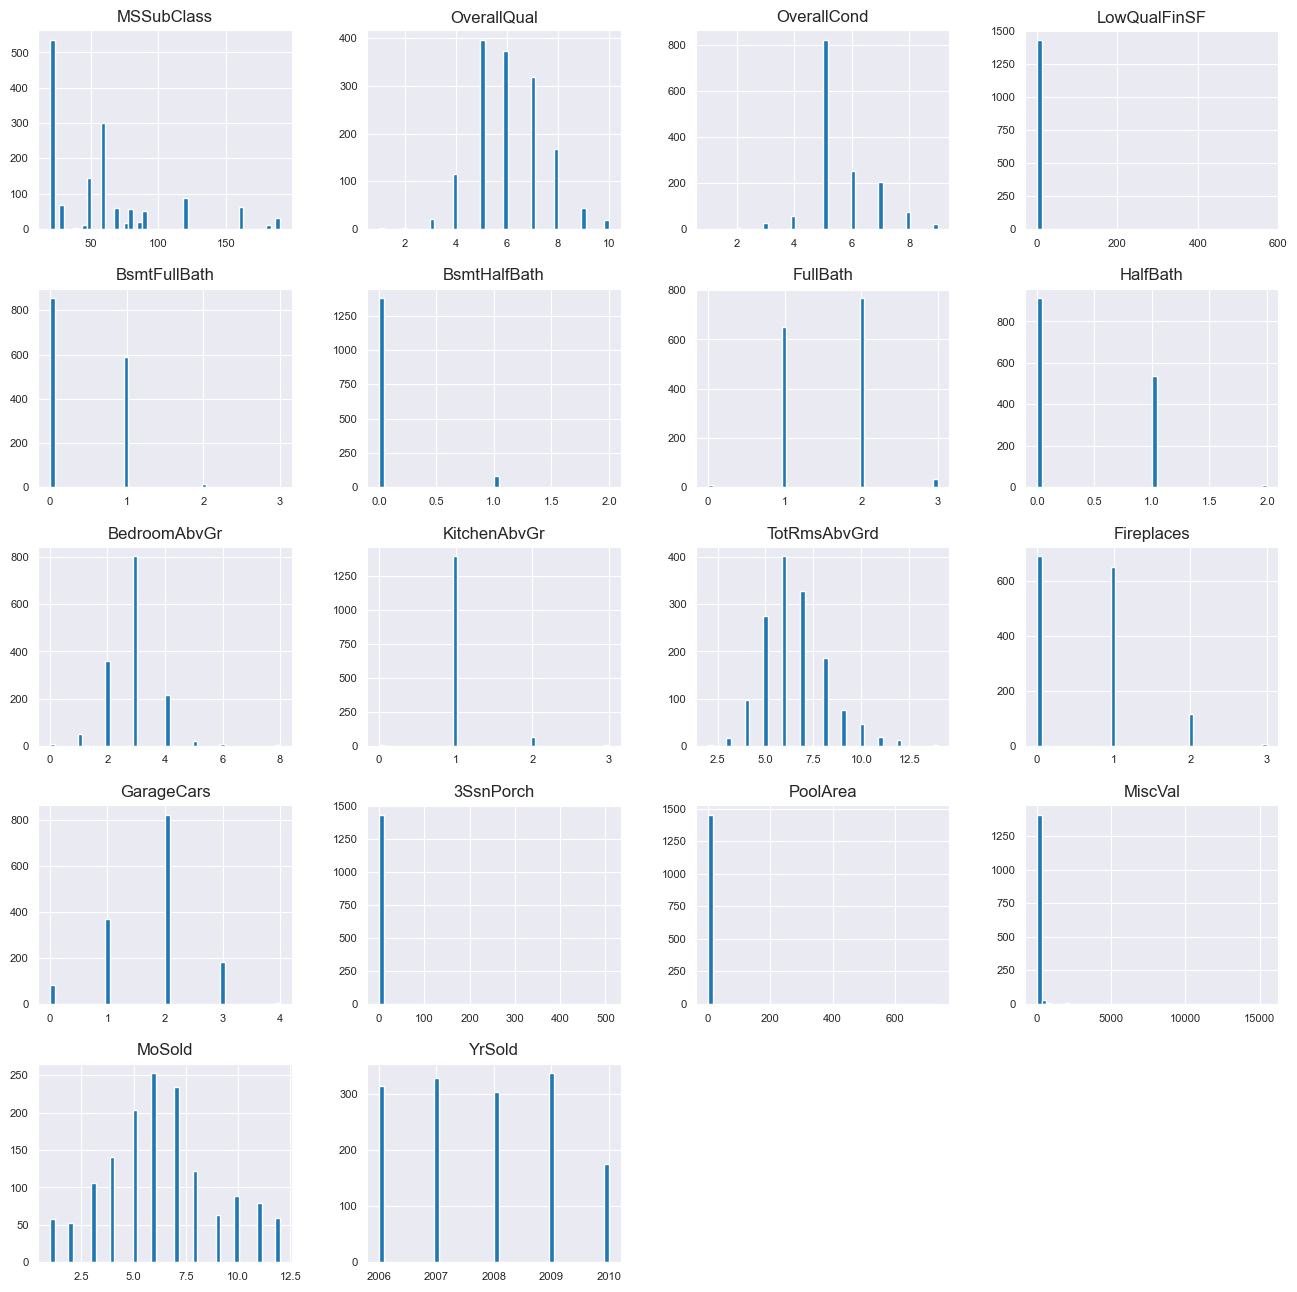

In [22]:
train[numerical_features].loc[:, train.nunique() < 30].hist(figsize=(16, 16), bins=50, xlabelsize=8, ylabelsize=8)
plt.show()

In [23]:
# It looks like numerical features are LowQualFinSF,  3SsnPorch, PoolArea, MiscVal, other categorical
categorical_features = categorical_features.append(train[numerical_features].loc[:, train.nunique() < 30].drop(['LowQualFinSF',  '3SsnPorch', 'PoolArea', 'MiscVal'], axis=1).columns)
numerical_features = numerical_features.drop(train[numerical_features].loc[:, train.nunique() < 30].drop(['LowQualFinSF',  '3SsnPorch', 'PoolArea', 'MiscVal'], axis=1).columns)

In [24]:
# 'YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt' are categorical features
categorical_features = categorical_features.to_list()
categorical_features.append('YearBuilt')
categorical_features.append('YearRemodAdd')
categorical_features.append('GarageYrBlt')

numerical_features = numerical_features.to_list()
numerical_features.remove('YearBuilt')
numerical_features.remove('YearRemodAdd')
numerical_features.remove('GarageYrBlt')
numerical_features.remove('SalePrice')

len(categorical_features)+len(numerical_features)

80

# FIRST ROUND <a class="anchor" id="6"></a>
[Table of Contents](#0.1)
### Baseline and fast start

In first round, we will compare usability. Which library requires minimal data preparation for building a baseline, which library has the most convenient built-in tools for working with categorical features and missing values. We will compare which library gives the most accurate prediction on the test data without using cross validation. 

Also, we will see which library will show the best score without custom data preparation, filling missing values and feature engineering. This result is not so important, just for completeness of study.

## LightGBM <a class="anchor" id="6.1"></a>
[Table of Contents](#0.1)

In [25]:
# Data Preparation
'''
LightGBM has built-in solutions for working with categorical features and NANs,
but we must to change the data types to categorical. So, so. 
At the first acquaintance with the library, it is not obvious and requires googling.
'''

train_copy = train.copy()
test_copy = test.copy()


def cat_features(df, categorical_features):
    for c in categorical_features:
        col_type = df[c].dtype
        if col_type == 'object':
            df[c] = df[c].astype('category')
    return df


train_copy = cat_features(train_copy, categorical_features)
test_copy = cat_features(test_copy, categorical_features)

X = train_copy.drop(['SalePrice'], axis=1).copy()
y = train_copy['SalePrice'].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
# Model
lgbm = LGBMRegressor()
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_val)

In [27]:
rmse_result = pd.DataFrame(index=['Train', 'Test', 'Diff'], columns=['LightGBM', 'XGBoost', 'CatBoost'])

In [28]:
rmse_result.iloc[0, 0] = mean_squared_error(np.log(y_pred), np.log(y_val))**0.5
rmse_result

,LightGBM,XGBoost,CatBoost
Train,0.135032,NaN,NaN
Test,NaN,NaN,NaN
Diff,NaN,NaN,NaN


In [29]:
# Prediction
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test['Id']
prediction.iloc[:, 1] = lgbm.predict(test_copy)
prediction.to_csv('submission.csv', index=False) # result 0.14546

In [30]:
rmse_result.iloc[1, 0] = 0.14546
rmse_result.iloc[2, 0] = abs(rmse_result.iloc[1, 0] - rmse_result.iloc[0, 0])
rmse_result

,LightGBM,XGBoost,CatBoost
Train,0.135032,NaN,NaN
Test,0.14546,NaN,NaN
Diff,0.010428,NaN,NaN


## XGBoost <a class="anchor" id="6.2"></a>
[Table of Contents](#0.1)

In [31]:
# Data Preparation
'''
XGBoost does not have built-in solutions for working with categorical features, 
we will have to use third-party libraries and write additional data processing.
It turns out LightGBM is not so bad)
'''

train_copy = train.copy()
test_copy = test.copy()
df = pd.concat([train_copy, test_copy], axis=0)

cat_encoder = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse = False)
std_scaler = StandardScaler()


def create_dataset(df, categorical_cols, numerical_cols):
    df_ohe = cat_encoder.fit_transform(df[categorical_cols])
    numerical_cols_std_scaled = std_scaler.fit_transform(df[numerical_cols])
    X_cat = pd.DataFrame(df_ohe, columns=cat_encoder.get_feature_names_out())
    X_num = pd.DataFrame(numerical_cols_std_scaled, columns=numerical_cols)
    X = pd.concat([X_cat, X_num], axis=1)
    df = df.reset_index()
    X_test = X[df['SalePrice'].isnull()].copy()
    X = X[df['SalePrice'].notnull()].copy()
    return X, X_test
    
    
y = train_copy['SalePrice']
X, X_test = create_dataset(df, categorical_features, numerical_features)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
# Model
xgboost = XGBRegressor()
xgboost.fit(X_train, y_train)
y_pred = xgboost.predict(X_val)

In [33]:
rmse_result.iloc[0, 1] = mean_squared_error(np.log(y_pred), np.log(y_val))**0.5
rmse_result

,LightGBM,XGBoost,CatBoost
Train,0.135032,0.152235,NaN
Test,0.14546,NaN,NaN
Diff,0.010428,NaN,NaN


In [34]:
# Prediction
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_copy['Id']
prediction.iloc[:, 1] = xgboost.predict(X_test)
prediction.to_csv('submission.csv', index=False) # result 0.16584

In [35]:
rmse_result.iloc[1, 1] = 0.16584
rmse_result.iloc[2, 1] = abs(rmse_result.iloc[1, 1] - rmse_result.iloc[0, 1])
rmse_result

,LightGBM,XGBoost,CatBoost
Train,0.135032,0.152235,NaN
Test,0.14546,0.16584,NaN
Diff,0.010428,0.013605,NaN


## CatBoost <a class="anchor" id="6.3"></a>
[Table of Contents](#0.1)

In [36]:
# Data Preparation
'''
CatBoost has built-in solutions for working with categorical features and NANs, 
but we have to change the data types to categorical, like in LightGBM.
According to subjective feelings, work with categorical features in catboost is implemented a little more intuitively.
'''

train_copy = train.copy()
test_copy = test.copy()

train_copy[categorical_features] = train_copy[categorical_features].astype(str)
test_copy[categorical_features] = test_copy[categorical_features].astype(str)

X = train_copy.drop(['SalePrice'], axis=1)
y = train_copy['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [37]:
# Model
ctb = CatBoostRegressor()
ctb.fit(X_train, y_train, cat_features=X_train.columns.get_indexer(categorical_features), verbose=False)
y_pred = ctb.predict(X_val)

In [38]:
rmse_result.iloc[0, 2] = mean_squared_error(np.log(y_pred), np.log(y_val))**0.5
rmse_result

,LightGBM,XGBoost,CatBoost
Train,0.135032,0.152235,0.128658
Test,0.14546,0.16584,NaN
Diff,0.010428,0.013605,NaN


In [39]:
# Prediction
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_copy['Id']
prediction.iloc[:, 1] = ctb.predict(test_copy)
prediction.to_csv('submission.csv', index=False)  # result 0.1566

In [40]:
rmse_result.iloc[1, 2] = 0.1566
rmse_result.iloc[2, 2] = abs(rmse_result.iloc[1, 2] - rmse_result.iloc[0, 2])
rmse_result

,LightGBM,XGBoost,CatBoost
Train,0.135032,0.152235,0.128658
Test,0.14546,0.16584,0.1566
Diff,0.010428,0.013605,0.027942


# CONCLUSIONS <a class="anchor" id="7"></a>
[Table of Contents](#0.1)

In first round LightGBM wins.
In my opinion, LightGBM is easiest to building a baseline and it showed the best score. It also has the smallest difference between train and test.

In [41]:
winners_list = pd.DataFrame(index=['LightGBM', 'XGBoost', 'CatBoost'])
winners_list['First Round'] = [1, 0, 0]
winners_list

,First Round
LightGBM,1
XGBoost,0
CatBoost,0


# SECOND ROUND <a class="anchor" id="8"></a>
[Table of Contents](#0.1)

### Target hit

In the second round, we will evaluate RMSE score of the prediction and  the speed of training. We will do a more detailed EDA, fill missing values, do feature engineering and hyperparameter optimization.

# EDA <a class="anchor" id="8.1"></a>
[Table of Contents](#0.1)

In [42]:
train_test = pd.concat([train, test])
train_test = train_test.reset_index()
train_test = train_test.drop(['index'], axis=1)
train_test_encode = train_test.copy()
train_test.shape

(2919, 81)

In [43]:
cat_features_to_encode = train_test.columns[train_test.dtypes == 'object'].to_list()
len(cat_features_to_encode)

43

In [44]:
encoders = dict()

for feature in cat_features_to_encode:
    series = train_test_encode[feature]
    lbl = LabelEncoder()
    train_test_encode[feature] = pd.Series(lbl.fit_transform(series[series.notnull()]), index=series[series.notnull()].index)
    encoders[feature] = lbl

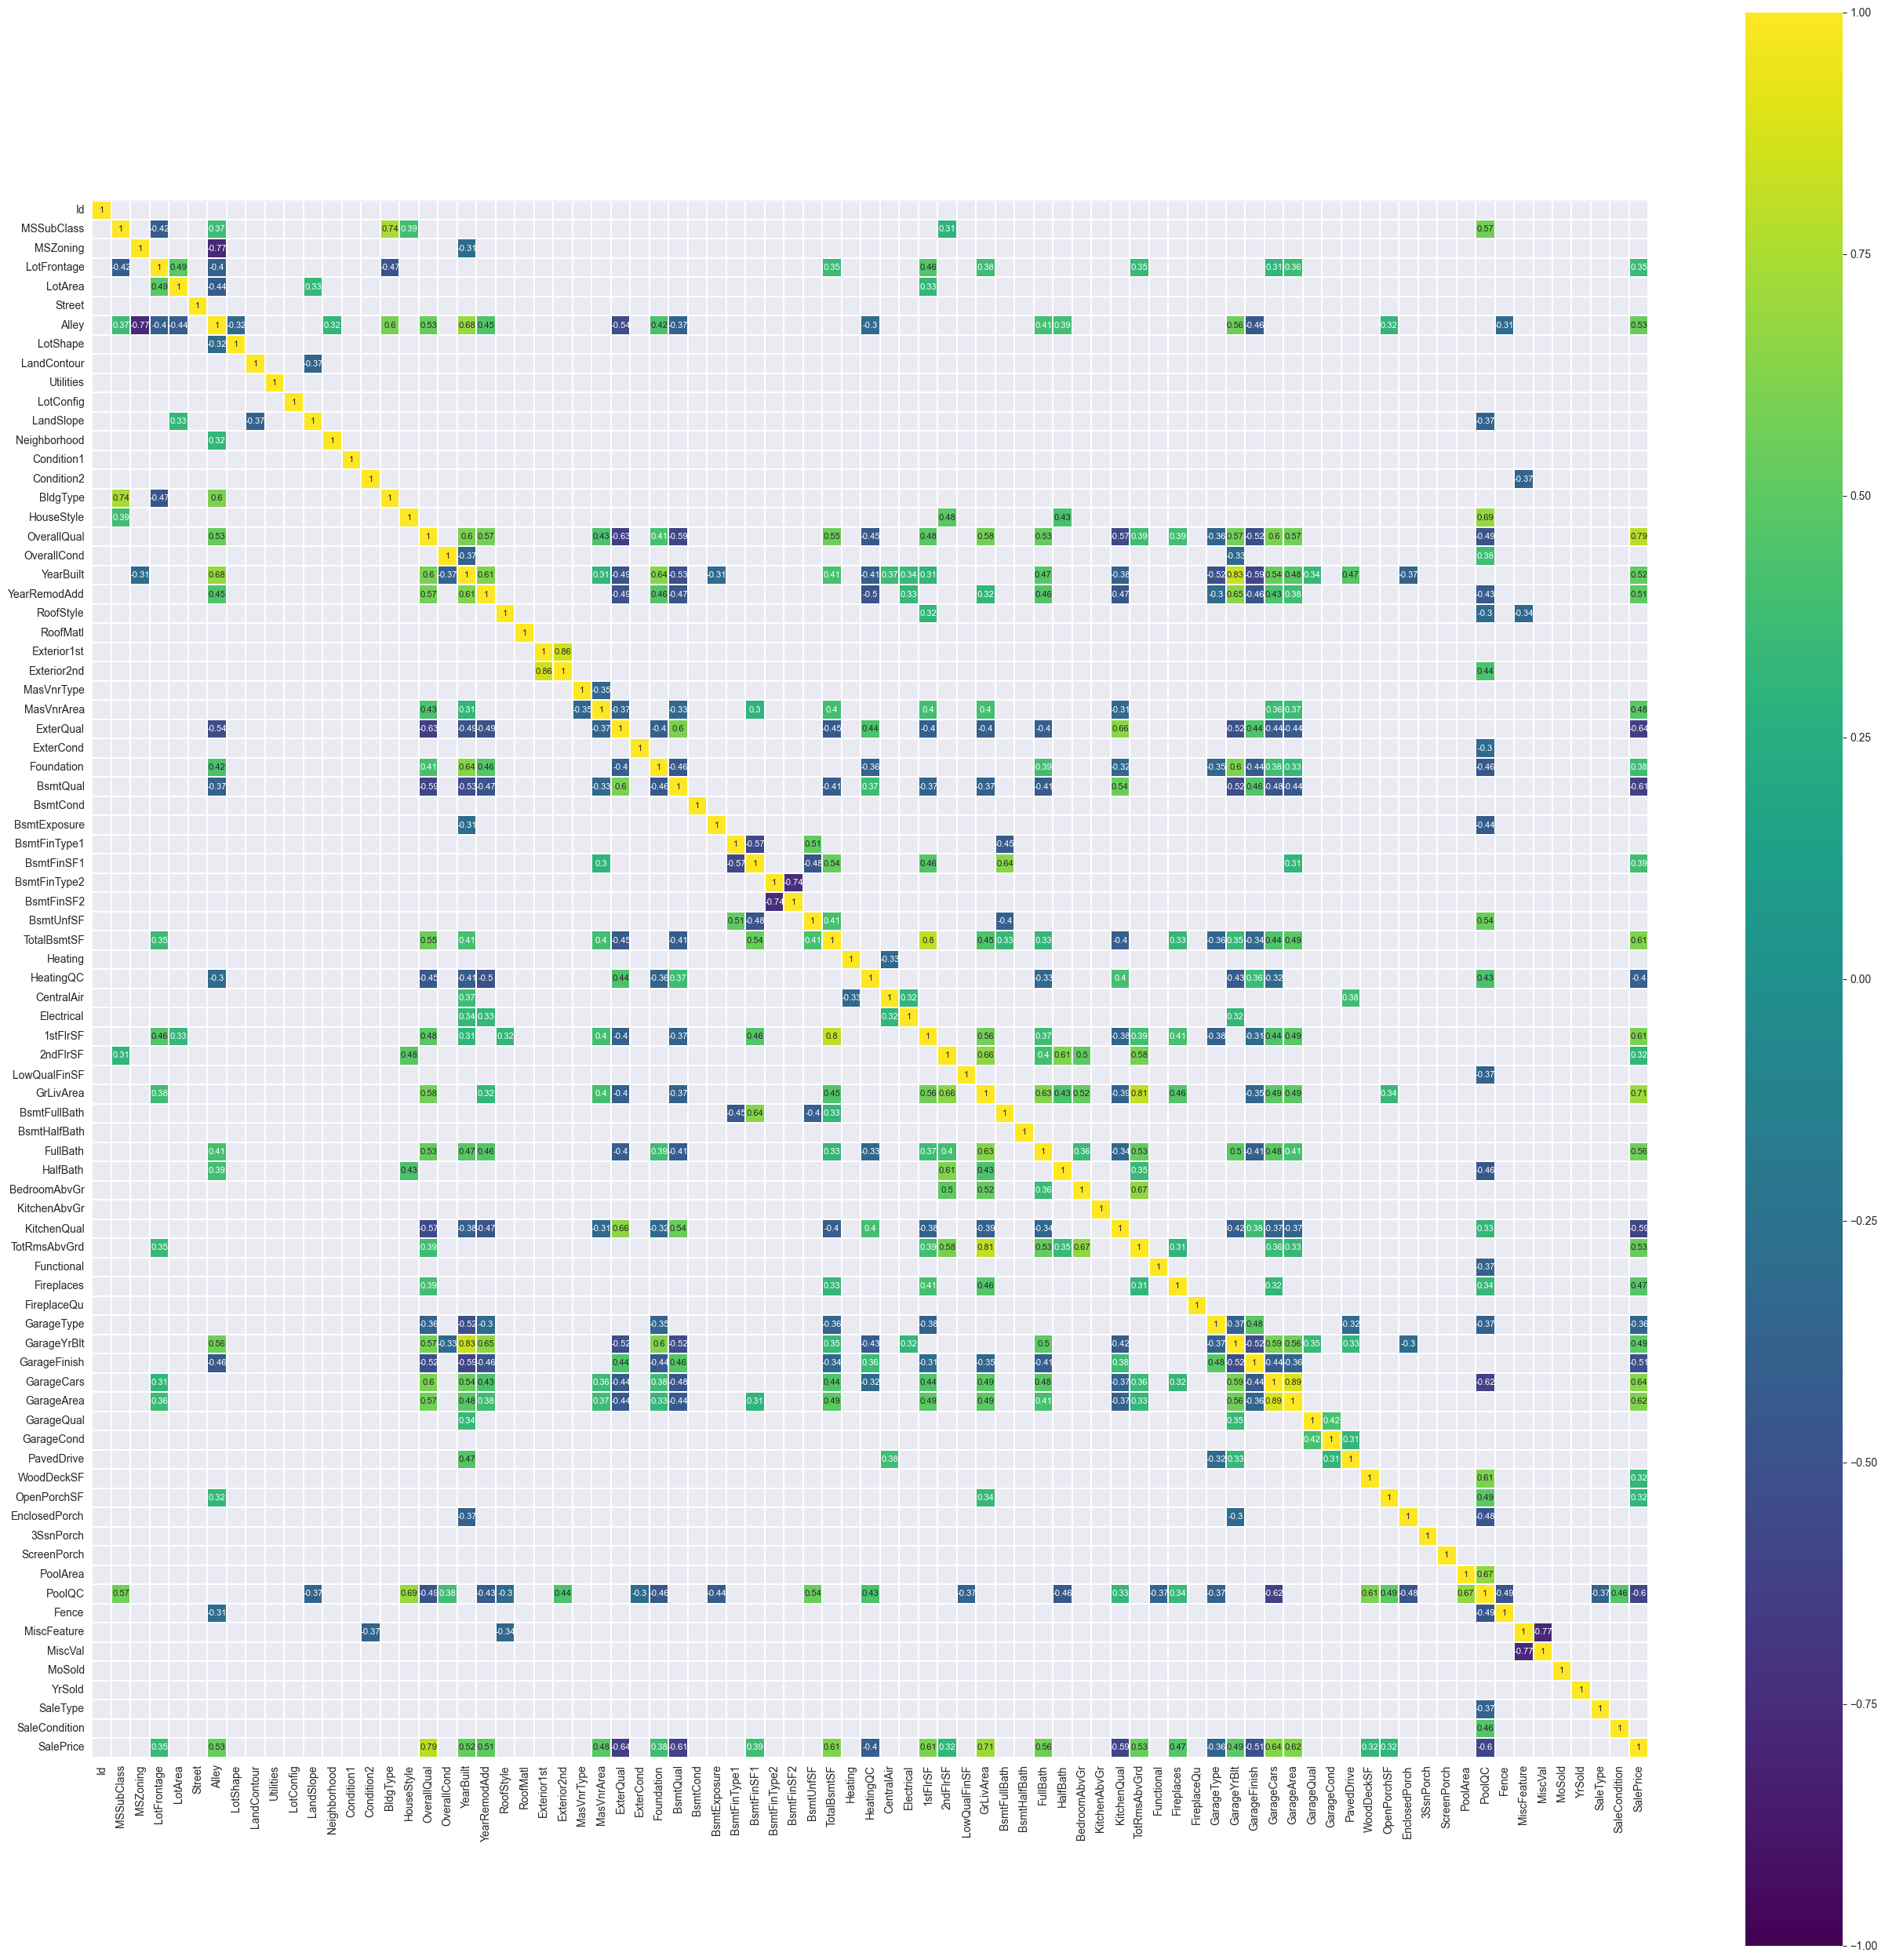

In [45]:
# Correlation matrix
corr_matrix = train_test_encode.corr()

plt.figure(figsize=(32, 32))
sns.heatmap(corr_matrix[(corr_matrix >= 0.3) | (corr_matrix <= -0.3)], 
            cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 8}, square=True);

In [46]:
len(corr_matrix)

81

In [47]:
# Let's find the features that the most correlate with the target.
corr_table = corr_matrix.stack().reset_index()
corr_table.columns = ['Feat_1', 'Feat_2', 'Corr']
corr_table['Corr_abs'] = abs(corr_table['Corr'])

corr_table = corr_table[['Feat_2', 'Corr', 'Corr_abs']][(corr_table['Feat_1'] == 'SalePrice') & (corr_table['Feat_2'] != 'SalePrice')].sort_values('Corr_abs', ascending=False)
corr_table.head(30)

,Feat_2,Corr,Corr_abs
6455,OverallQual,0.790982,0.790982
6484,GrLivArea,0.708624,0.708624
6499,GarageCars,0.640409,0.640409
6465,ExterQual,-0.636884,0.636884
6500,GarageArea,0.623431,0.623431
6476,TotalBsmtSF,0.613581,0.613581
6468,BsmtQual,-0.611179,0.611179
6481,1stFlrSF,0.605852,0.605852
6510,PoolQC,-0.595229,0.595229
6491,KitchenQual,-0.589189,0.589189


In [48]:
corr_features = corr_table['Feat_2'].head(30).tolist()

corr_features.remove('YearBuilt')
corr_features.remove('YearRemodAdd')
corr_features.remove('GarageYrBlt')

# yields the elements in `corr_features` that are NOT in `numerical_features`
corr_categorical_features = np.setdiff1d(corr_features, numerical_features)
# yields the elements in `corr_features` that are NOT in `categorical_features`
corr_numerical_features = np.setdiff1d(corr_features, categorical_features)

time_series = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

In [49]:
# Let's find the features that the most correlate each other.
corr_feat_feat = corr_matrix.stack().reset_index()
corr_feat_feat.columns = ['Feat_1', 'Feat_2', 'Corr']
corr_feat_feat['Corr_abs'] = abs(corr_feat_feat['Corr'])
corr_feat_feat = corr_feat_feat.drop_duplicates(subset=['Corr'])
corr_feat_feat[(corr_feat_feat['Feat_1'] != 'SalePrice') & (corr_feat_feat['Feat_2'] != 'SalePrice')\
                & (corr_feat_feat['Feat_1'] != corr_feat_feat['Feat_2'])].sort_values('Corr_abs', ascending=False).head(40)

,Feat_1,Feat_2,Corr,Corr_abs
4981,GarageCars,GarageArea,0.889700,0.889700
1870,Exterior1st,Exterior2nd,0.855686,0.855686
1581,YearBuilt,GarageYrBlt,0.834812,0.834812
3759,GrLivArea,TotRmsAbvGrd,0.808354,0.808354
3103,TotalBsmtSF,1stFlrSF,0.801670,0.801670
168,MSZoning,Alley,-0.768519,0.768519
6027,MiscFeature,MiscVal,-0.766245,0.766245
2853,BsmtFinType2,BsmtFinSF2,-0.743554,0.743554
96,MSSubClass,BldgType,0.741508,0.741508
1351,HouseStyle,PoolQC,0.687343,0.687343


In [50]:
# Categorical features
len(corr_categorical_features)

16

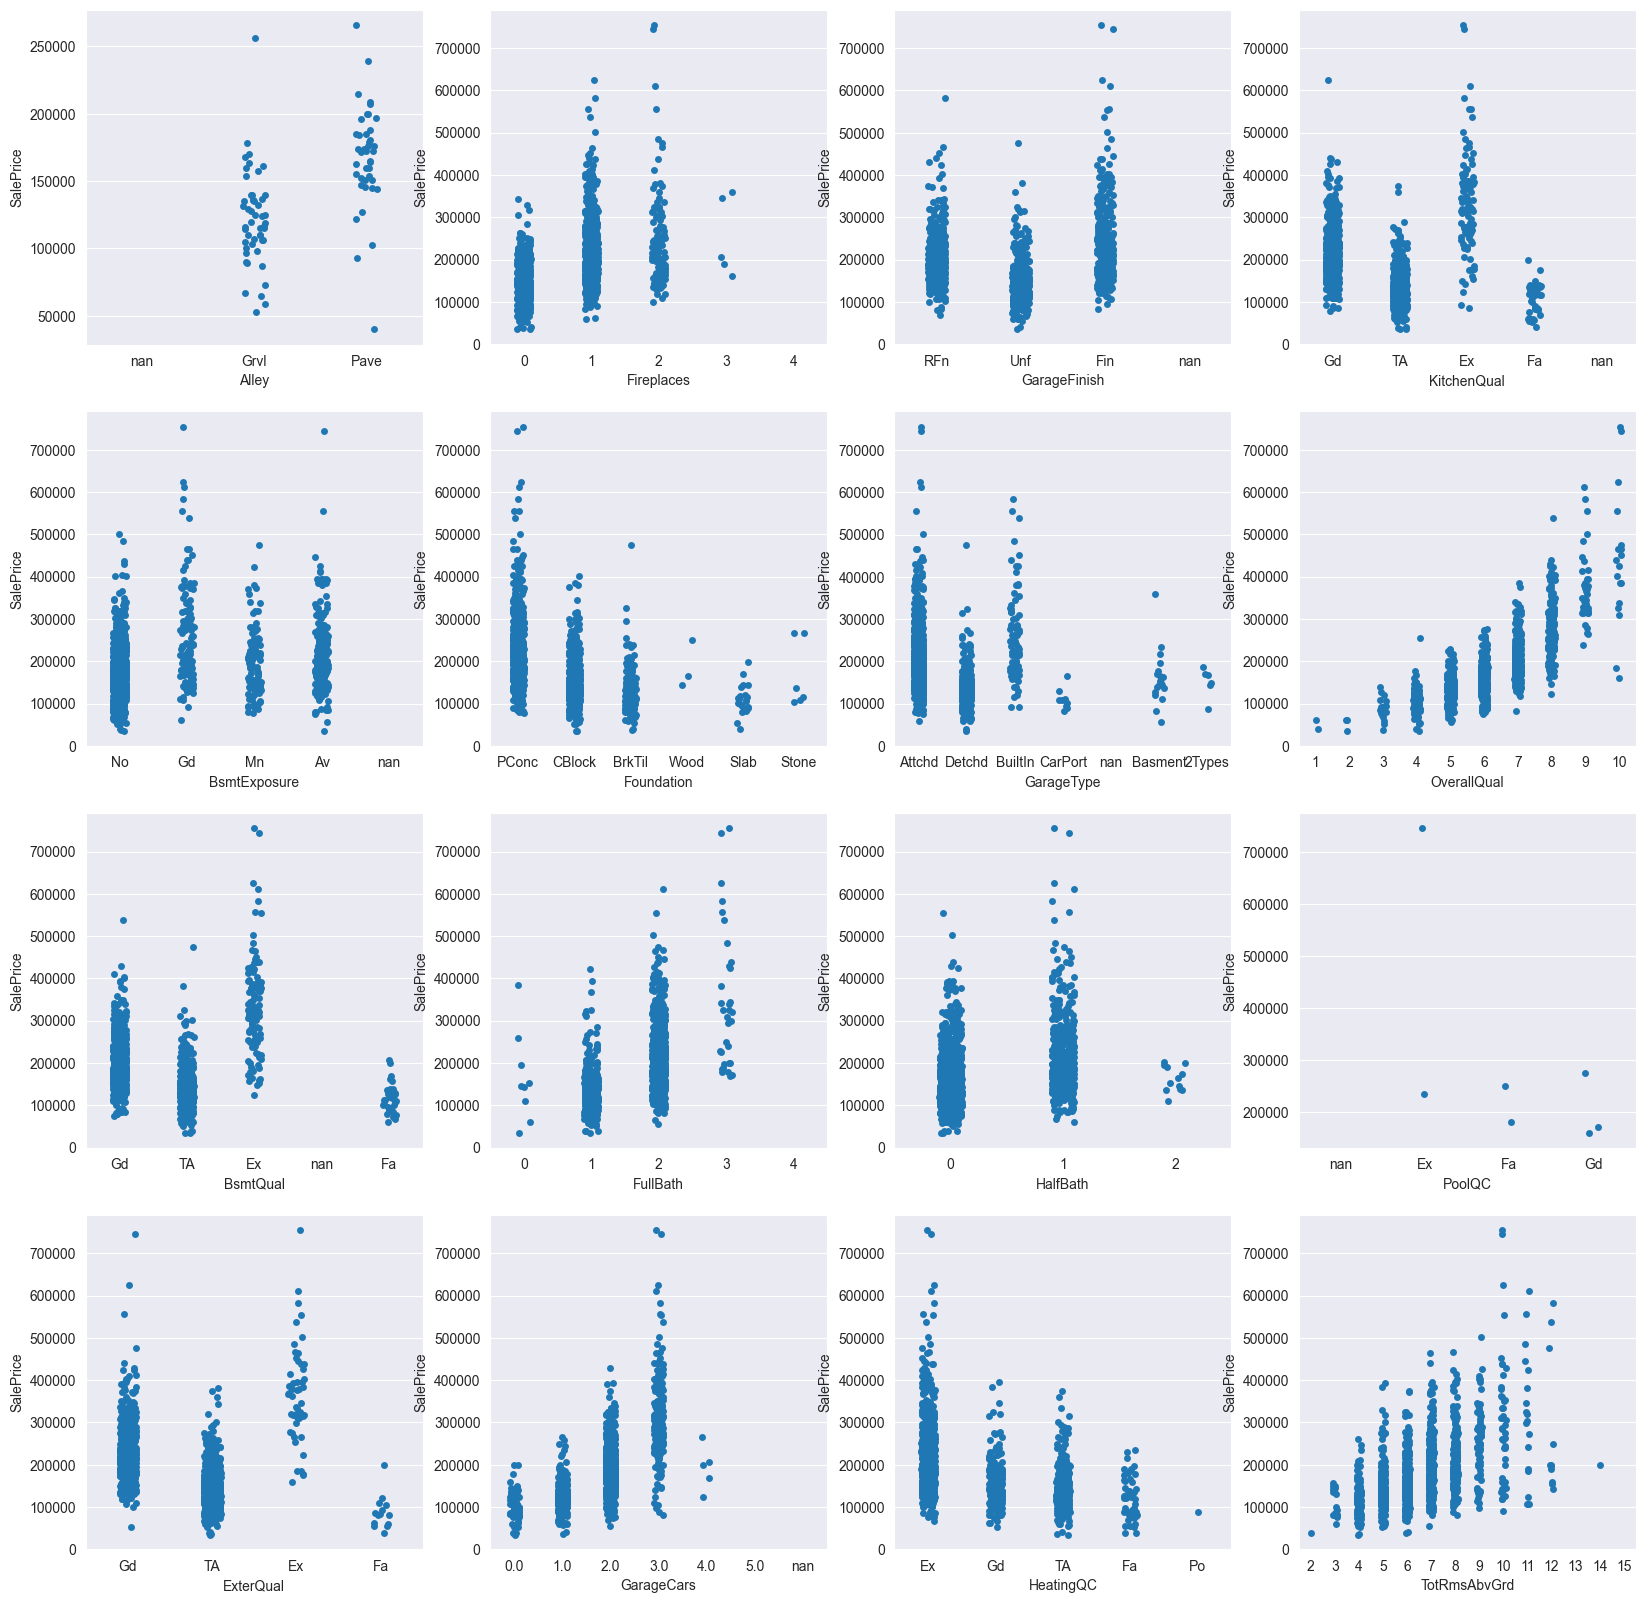

In [51]:
figure, ax = plt.subplots(4 ,len(corr_categorical_features)//4, figsize = (20,20))
cnt = 0
for i, v in zip(range(len(corr_categorical_features)), corr_categorical_features):
    if i % 4 == 0: 
        sns.stripplot(data=train_test, x = v, y='SalePrice', ax = ax[0, cnt])
    elif (i-1) % 4 == 0:
        sns.stripplot(data=train_test, x = v, y='SalePrice', ax = ax[1, cnt])
    elif (i-2) % 4 == 0:
        sns.stripplot(data=train_test, x = v, y='SalePrice', ax = ax[2, cnt])
    elif (i-3) % 4 == 0:
        sns.stripplot(data=train_test, x = v, y='SalePrice', ax = ax[3, cnt])
        cnt += 1

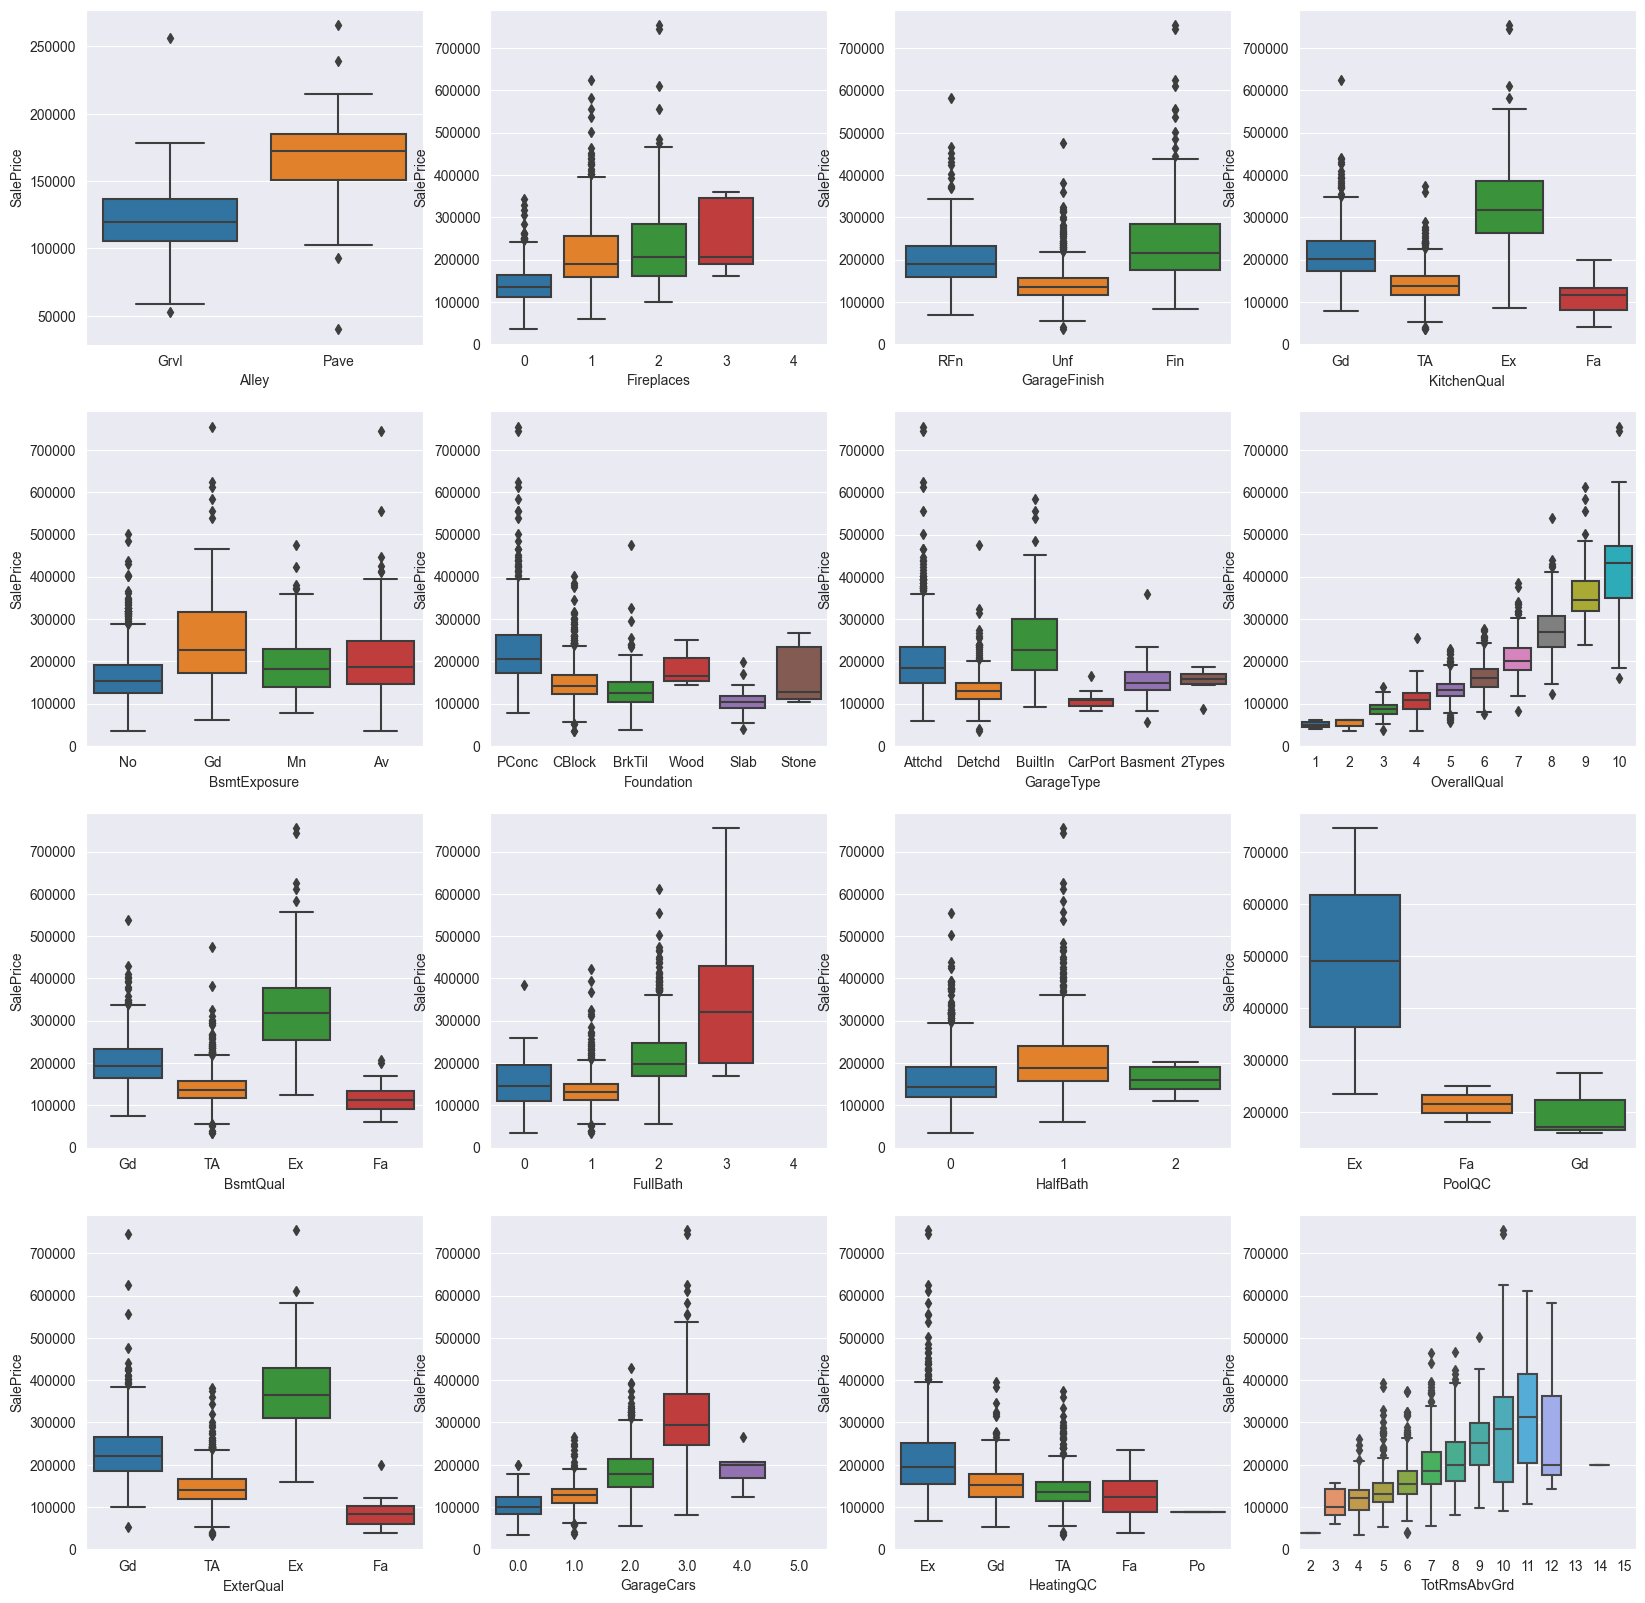

In [52]:
figure, ax = plt.subplots(4 ,len(corr_categorical_features)//4, figsize = (20,20))
cnt = 0
for i, v in zip(range(len(corr_categorical_features)), corr_categorical_features):
    if i % 4 == 0: 
        sns.boxplot(data=train_test, x = v, y='SalePrice', ax = ax[0, cnt])
    elif (i-1) % 4 == 0:
        sns.boxplot(data=train_test, x = v, y='SalePrice', ax = ax[1, cnt])
    elif (i-2) % 4 == 0:
        sns.boxplot(data=train_test, x = v, y='SalePrice', ax = ax[2, cnt])
    elif (i-3) % 4 == 0:
        sns.boxplot(data=train_test, x = v, y='SalePrice', ax = ax[3, cnt])
        cnt += 1

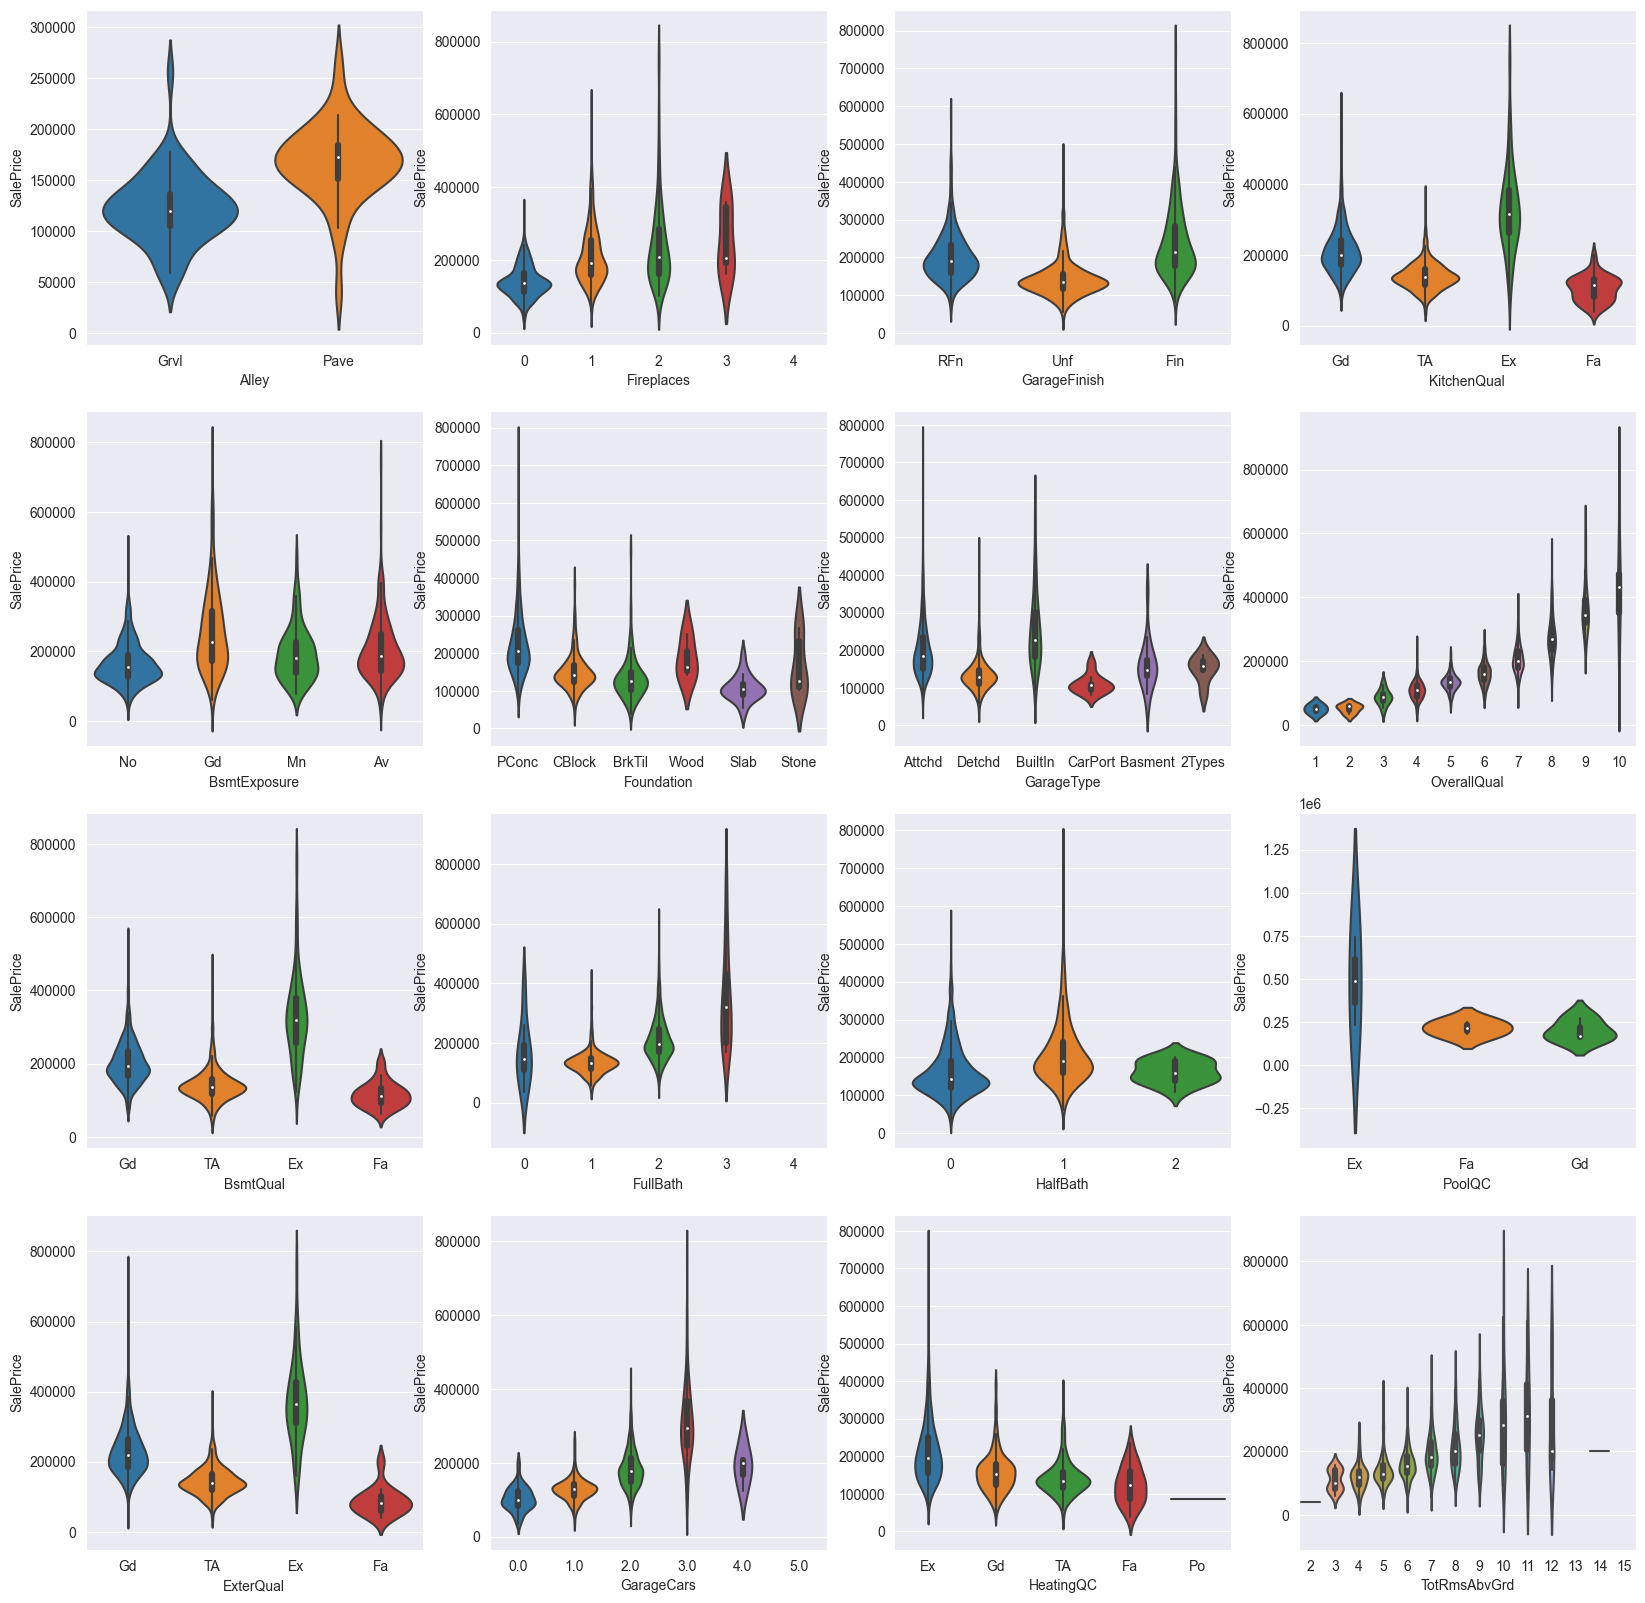

In [53]:
figure, ax = plt.subplots(4 ,len(corr_categorical_features)//4, figsize = (20,20))
cnt = 0
for i, v in zip(range(len(corr_categorical_features)), corr_categorical_features):
    if i % 4 == 0: 
        sns.violinplot(data=train_test, x = v, y='SalePrice', ax = ax[0, cnt])
    elif (i-1) % 4 == 0:
        sns.violinplot(data=train_test, x = v, y='SalePrice', ax = ax[1, cnt])
    elif (i-2) % 4 == 0:
        sns.violinplot(data=train_test, x = v, y='SalePrice', ax = ax[2, cnt])
    elif (i-3) % 4 == 0:
        sns.violinplot(data=train_test, x = v, y='SalePrice', ax = ax[3, cnt])
        cnt += 1

In [54]:
# Time series

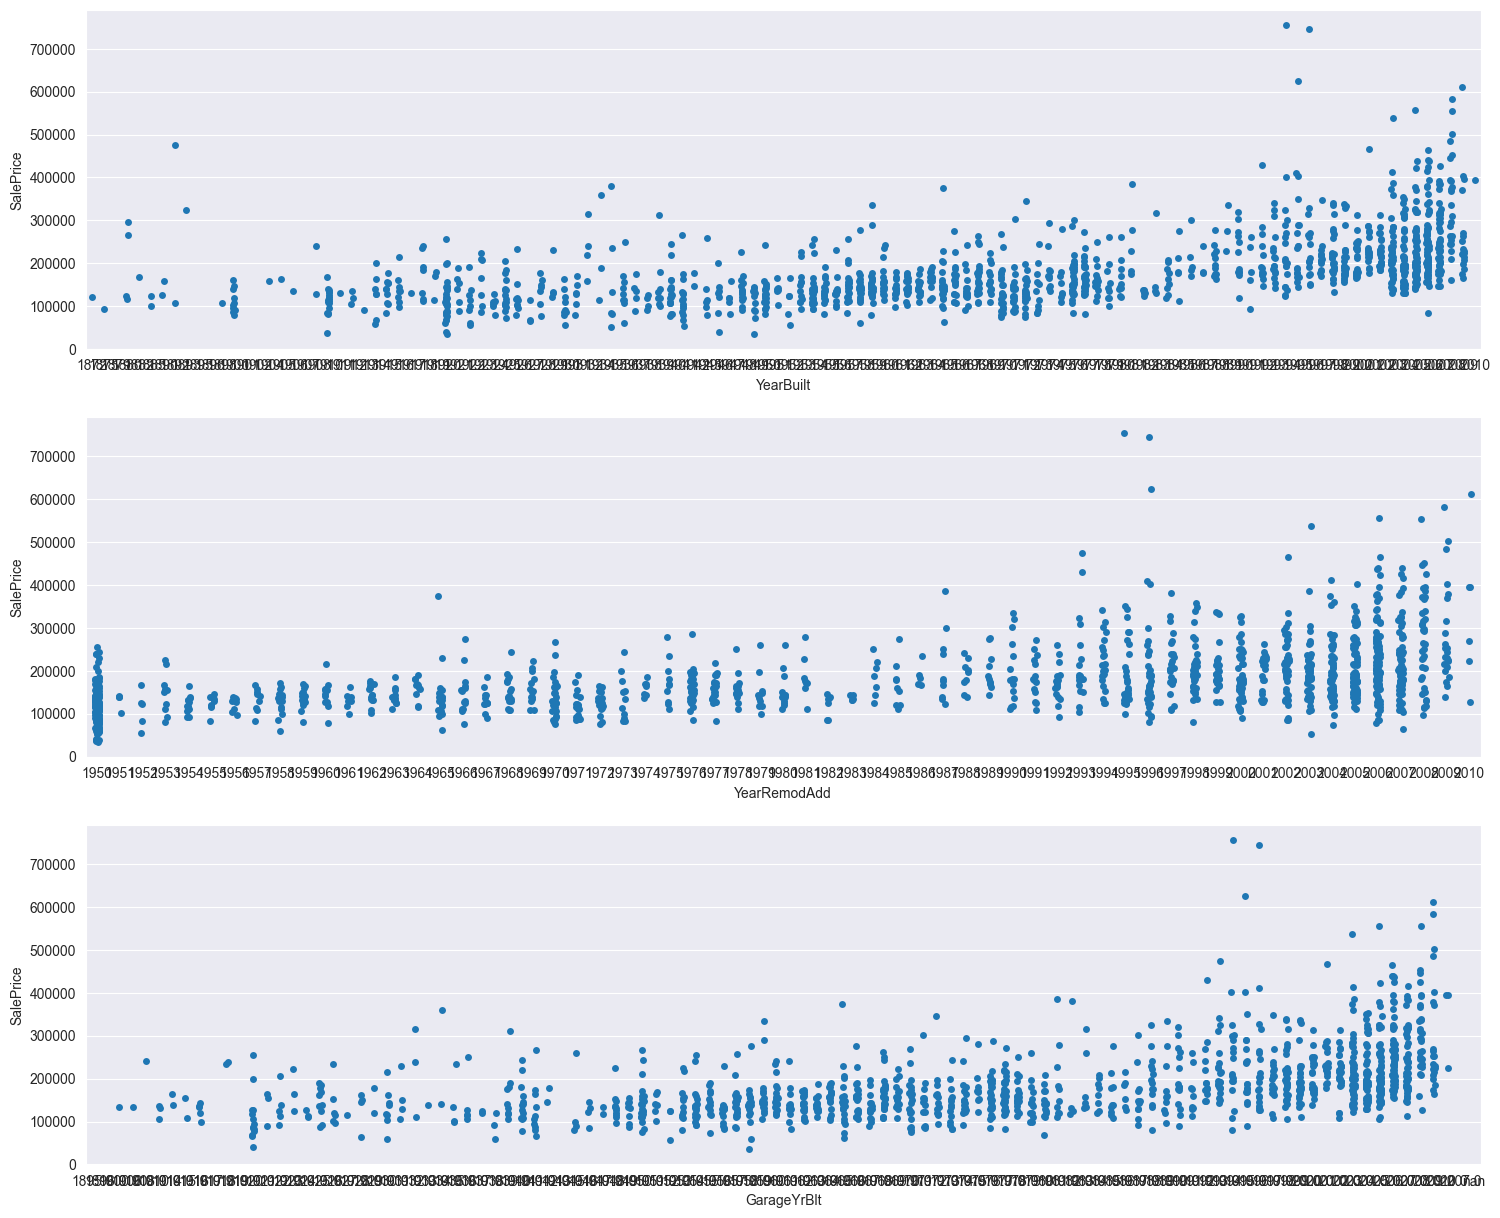

In [55]:
figure, ax = plt.subplots(len(time_series),1, figsize = (18,15))
for i, v in zip(range(len(time_series)), time_series):
    sns.stripplot(data=train_test, x = v, y='SalePrice', ax = ax[i])

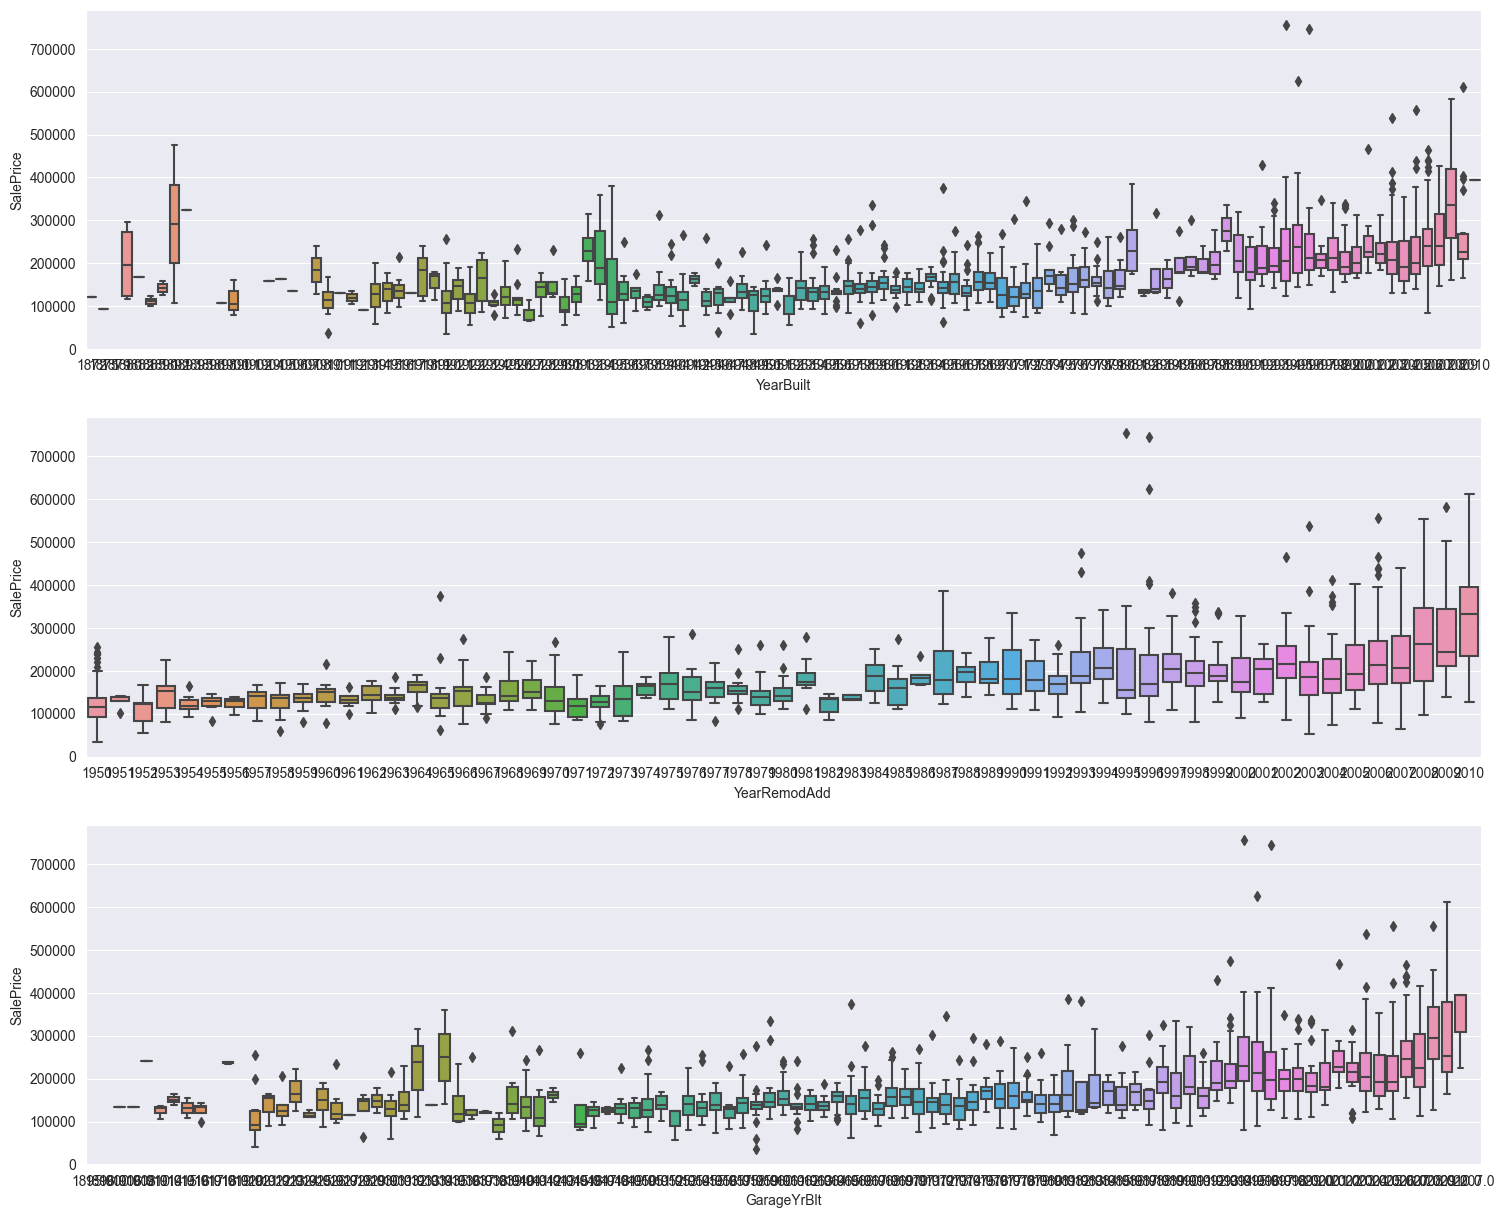

In [56]:
figure, ax = plt.subplots(len(time_series),1, figsize = (18,15))
for i, v in zip(range(len(time_series)), time_series):
    sns.boxplot(data=train_test, x = v, y='SalePrice', ax = ax[i])

In [57]:
# Numerical features
len(corr_numerical_features)

11

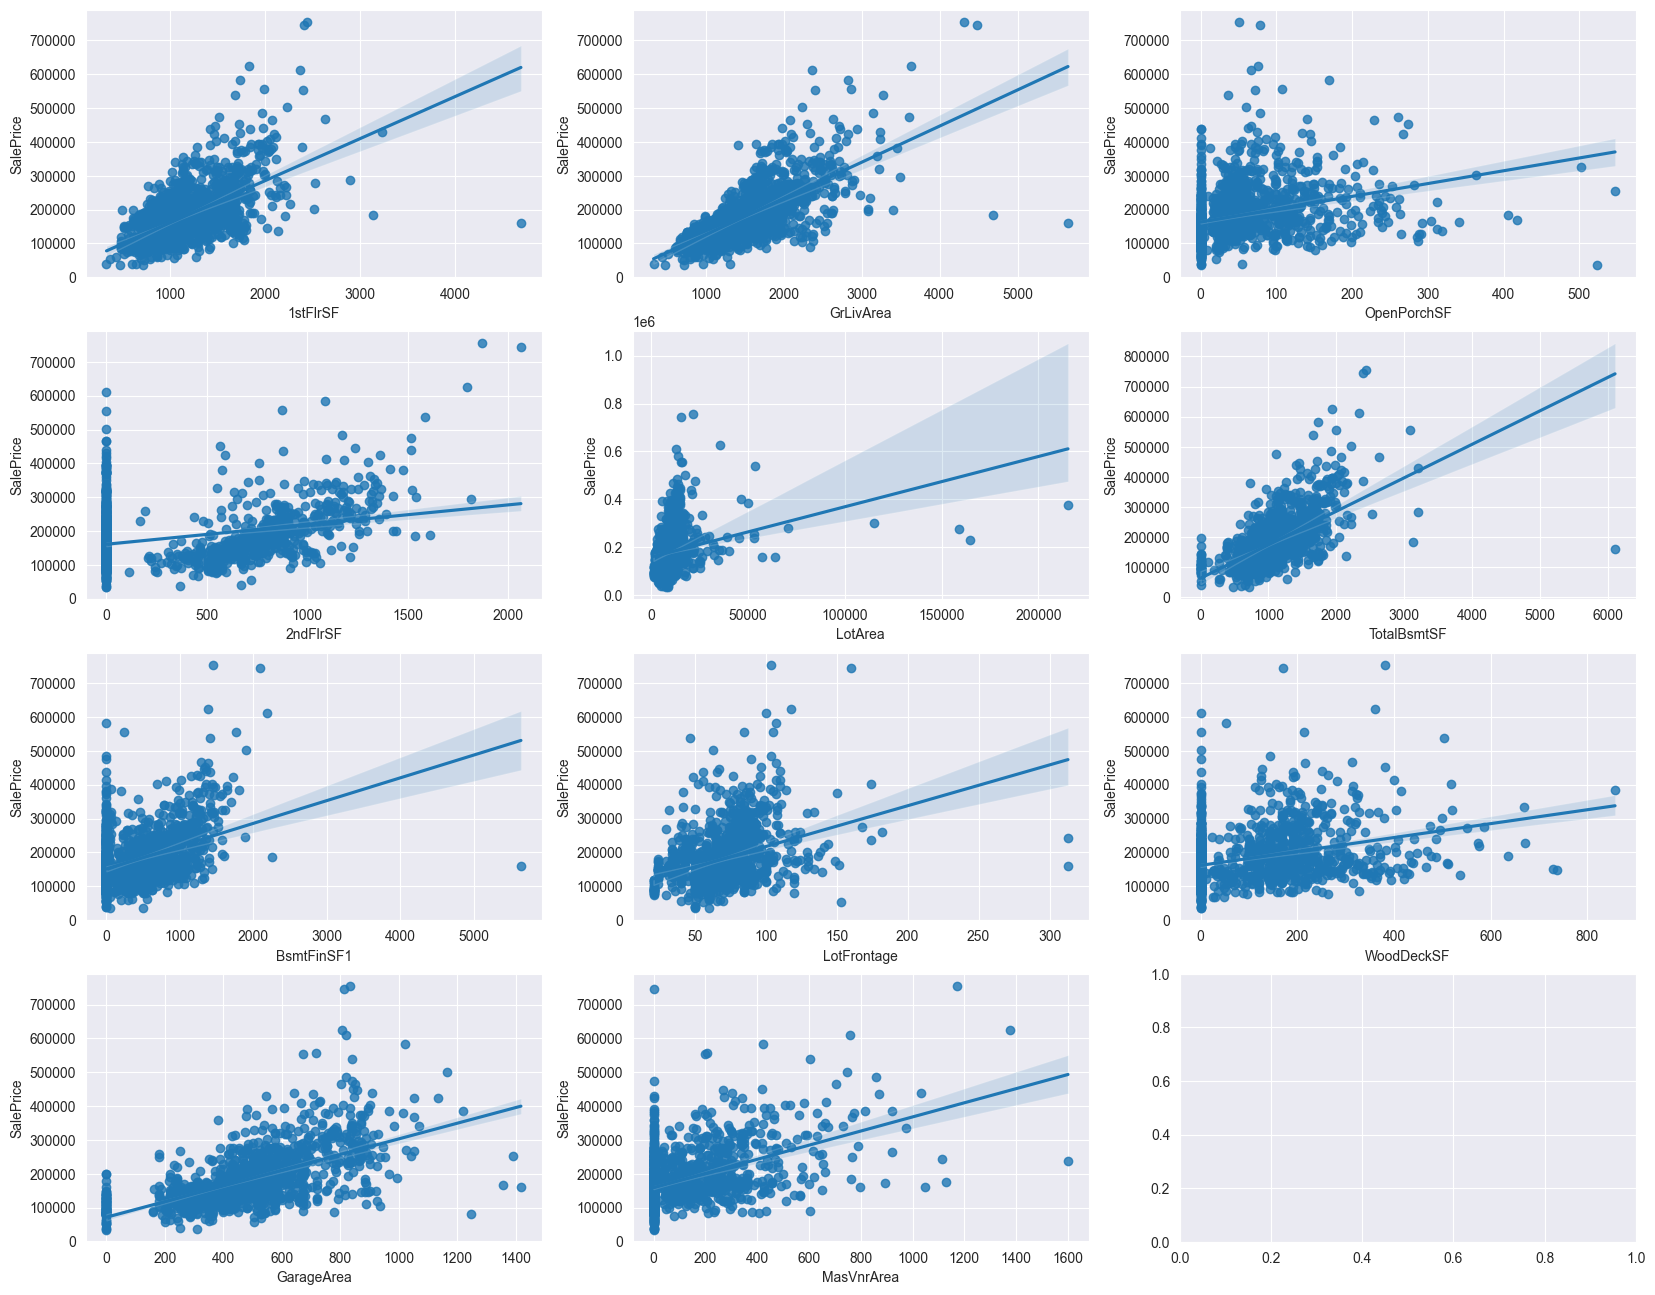

In [58]:
figure, ax = plt.subplots(4,len(corr_numerical_features)//3, figsize = (20,16))
cnt = 0
for i, v in zip(range(len(corr_numerical_features)), corr_numerical_features):
    if i % 4 == 0: 
        sns.regplot(data=train_test, x = v, y='SalePrice', ax = ax[0, cnt])
    elif (i - 1) % 4 == 0:
        sns.regplot(data=train_test, x = v, y='SalePrice', ax = ax[1, cnt])
    elif (i - 2) % 4 == 0:
        sns.regplot(data=train_test, x = v, y='SalePrice', ax = ax[2, cnt])
    elif (i - 3) % 4 == 0:
        sns.regplot(data=train_test, x = v, y='SalePrice', ax = ax[3, cnt])
        cnt += 1

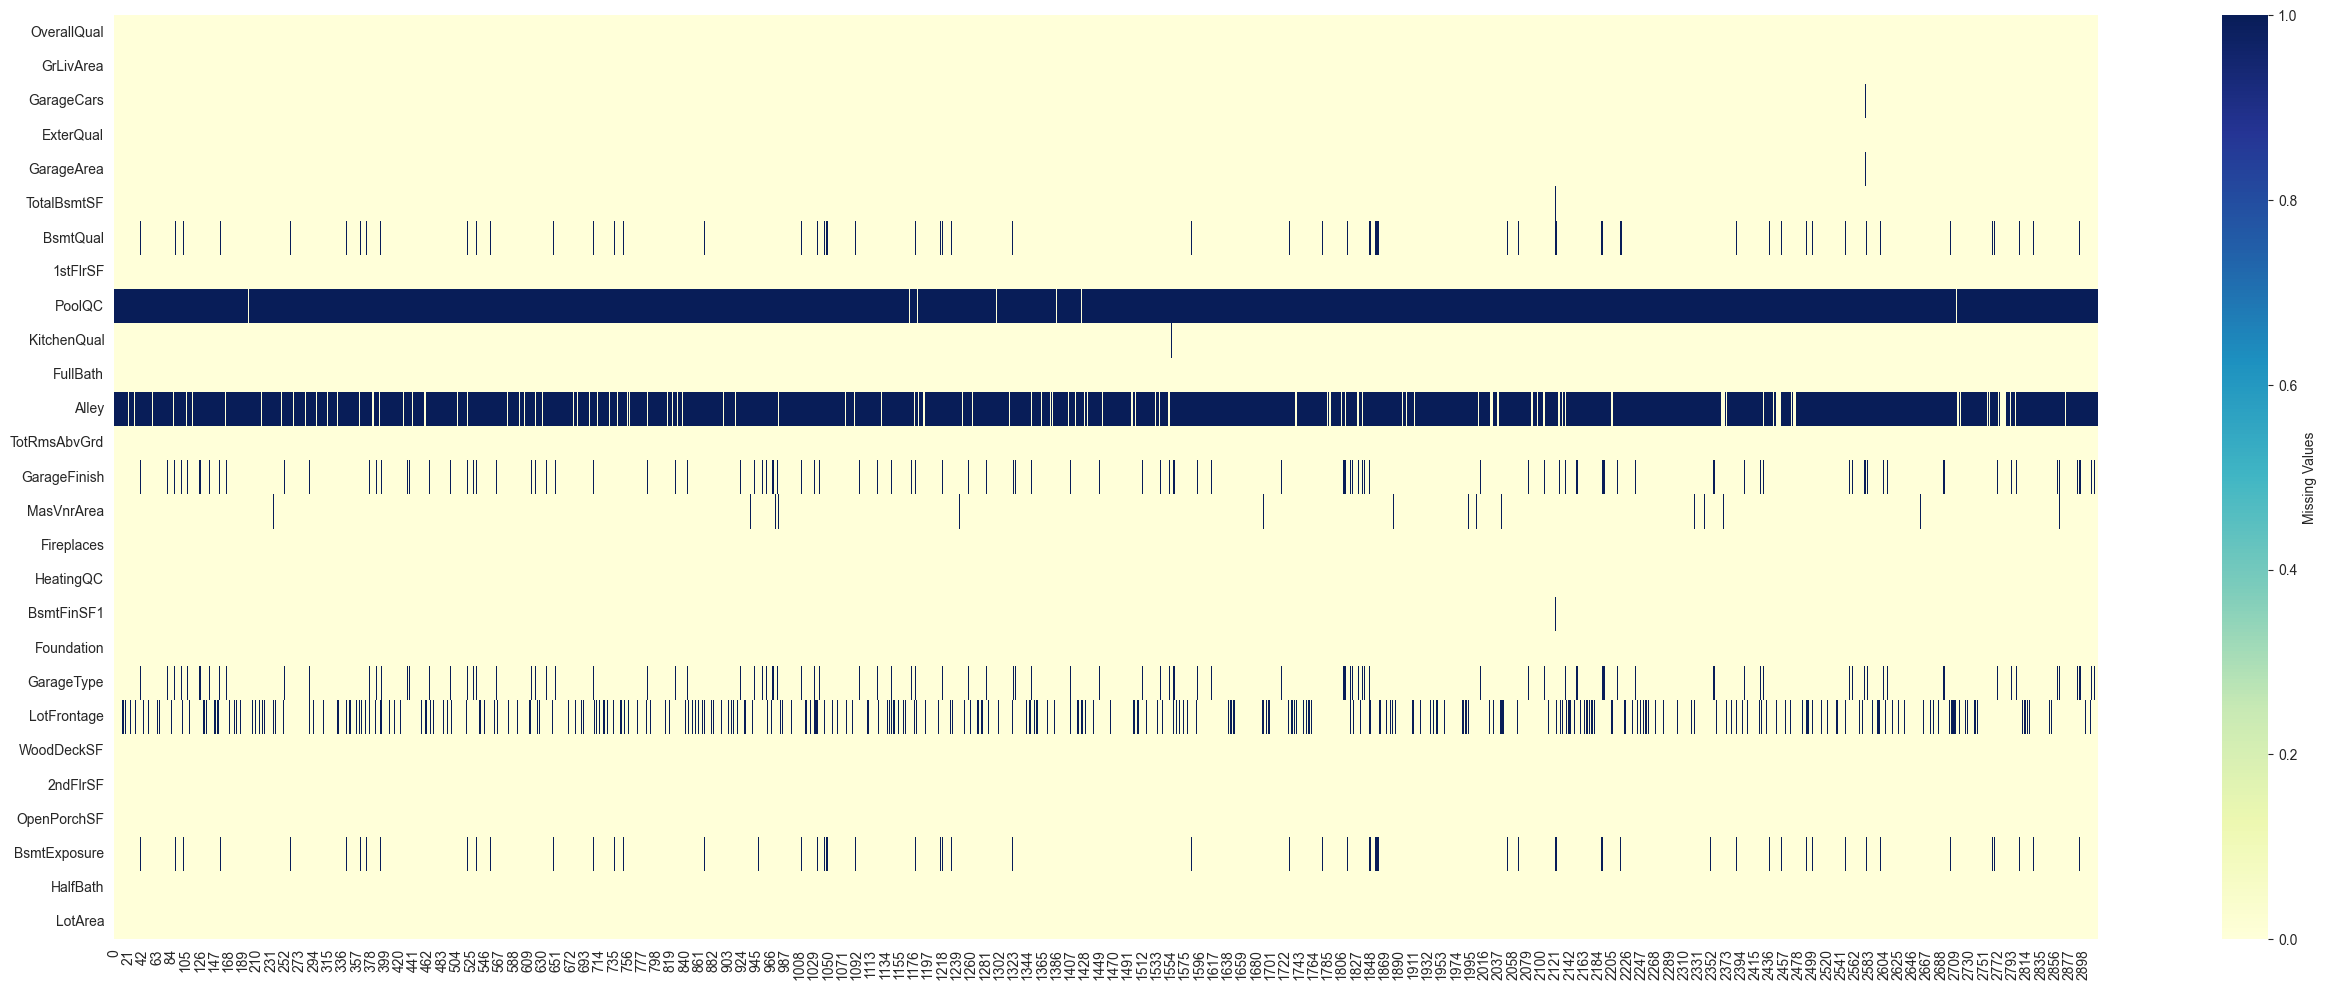

In [59]:
# Missing values
plt.figure(figsize=(32,12))
sns.heatmap(train_test[corr_features].isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Values'})
plt.show()

In [60]:
total = train_test.isnull().sum().sort_values(ascending=False)
percent = train_test.isnull().mean().sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,2909,0.996574
MiscFeature,2814,0.964029
Alley,2721,0.932169
Fence,2348,0.804385
SalePrice,1459,0.499829
FireplaceQu,1420,0.486468
LotFrontage,486,0.166495
GarageFinish,159,0.054471
GarageQual,159,0.054471
GarageCond,159,0.054471


In [61]:
corr_table = corr_table.set_index('Feat_2')

In [62]:
corr_table = pd.concat([corr_table, missing_data], axis=1)
corr_table.sort_values('Total', ascending=False).head(20)

,Corr,Corr_abs,Total,Percent
PoolQC,-0.595229,0.595229,2909,0.996574
MiscFeature,0.109485,0.109485,2814,0.964029
Alley,0.534319,0.534319,2721,0.932169
Fence,-0.172999,0.172999,2348,0.804385
SalePrice,NaN,NaN,1459,0.499829
FireplaceQu,-0.166817,0.166817,1420,0.486468
LotFrontage,0.351799,0.351799,486,0.166495
GarageQual,0.115119,0.115119,159,0.054471
GarageCond,0.150576,0.150576,159,0.054471
GarageFinish,-0.513105,0.513105,159,0.054471


In [63]:
corr_table.loc[corr_categorical_features].sort_values('Total', ascending=False)

,Corr,Corr_abs,Total,Percent
PoolQC,-0.595229,0.595229,2909,0.996574
Alley,0.534319,0.534319,2721,0.932169
GarageFinish,-0.513105,0.513105,159,0.054471
GarageType,-0.358279,0.358279,157,0.053786
BsmtExposure,-0.285290,0.285290,82,0.028092
BsmtQual,-0.611179,0.611179,81,0.027749
GarageCars,0.640409,0.640409,1,0.000343
KitchenQual,-0.589189,0.589189,1,0.000343
ExterQual,-0.636884,0.636884,0,0.000000
Fireplaces,0.466929,0.466929,0,0.000000


In [64]:
corr_table.loc[corr_numerical_features].sort_values('Total', ascending=False)

,Corr,Corr_abs,Total,Percent
LotFrontage,0.351799,0.351799,486,0.166495
MasVnrArea,0.477493,0.477493,23,0.007879
BsmtFinSF1,0.386420,0.386420,1,0.000343
GarageArea,0.623431,0.623431,1,0.000343
TotalBsmtSF,0.613581,0.613581,1,0.000343
1stFlrSF,0.605852,0.605852,0,0.000000
2ndFlrSF,0.319334,0.319334,0,0.000000
GrLivArea,0.708624,0.708624,0,0.000000
LotArea,0.263843,0.263843,0,0.000000
OpenPorchSF,0.315856,0.315856,0,0.000000


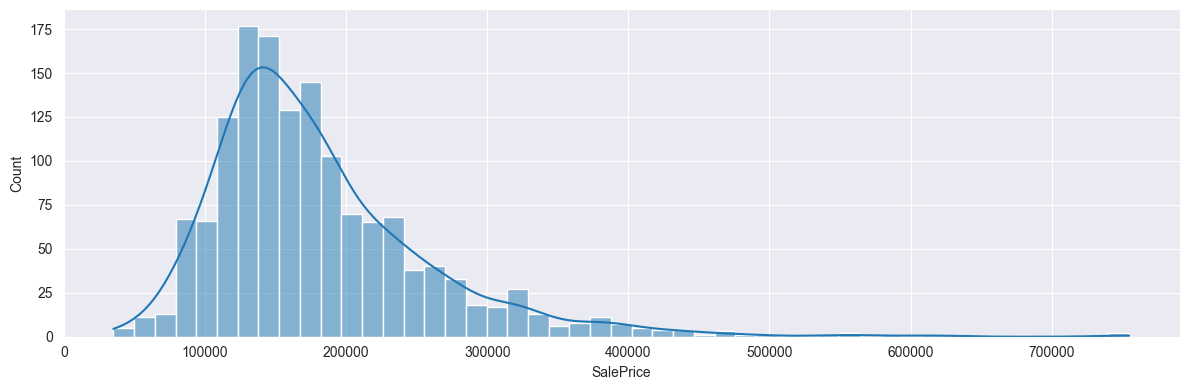

In [65]:
# Target
sns.displot(train_test['SalePrice'], kde = True, height=4, aspect=3)
plt.show()

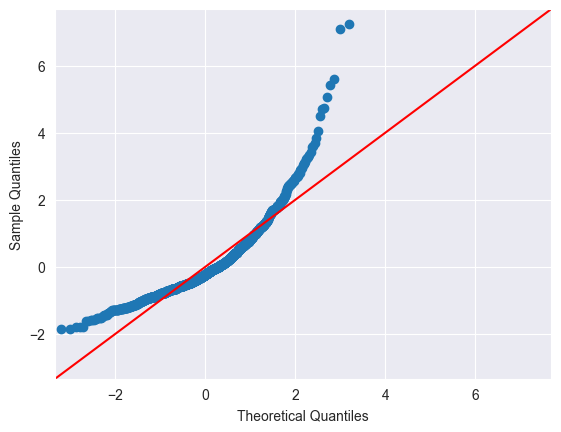

In [66]:
sm.qqplot(train['SalePrice'], stats.t, distargs=(4,), fit=True, line="45")
plt.show()

# FILLING MISSING VALUES <a class="anchor" id="8.2"></a>
[Table of Contents](#0.1)

In [67]:
# Filling PoolQC
train_test["PoolQC"] = train_test["PoolQC"].fillna('None')
train_test["PoolQC"].isna().sum()

0

In [68]:
# Filling Alley
train_test["Alley"] = train_test["Alley"].fillna('None')
train_test["Alley"].isna().sum()

0

In [69]:
# Filling MiscFeature
train_test['MiscFeature'] = train_test['MiscFeature'].fillna("None")
train_test["MiscFeature"].isna().sum()

0

In [70]:
# Filling 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
for col_name in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt']:
    train_test[col_name] = train_test[col_name].fillna('No')

train_test[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt']].isna().sum()

GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
GarageYrBlt     0
dtype: int64

In [71]:
# Filling 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
for col_name in ['BsmtQual', 'BsmtCond', 'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure']:
    train_test[col_name] = train_test[col_name].fillna('No')

train_test[['BsmtQual', 'BsmtCond', 'BsmtFinType1', 'BsmtFinType2']].isna().sum()

BsmtQual        0
BsmtCond        0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

In [72]:
# Filling FireplaceQu 
train_test['FireplaceQu'] = train_test['FireplaceQu'].fillna("None")
train_test["FireplaceQu"].isna().sum()

0

In [73]:
# Filling Fence 
train_test['Fence'] = train_test['Fence'].fillna("None")
train_test["Fence"].isna().sum()

0

In [74]:
for col_name in ['MasVnrArea', 'BsmtFinSF2', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'BsmtFinSF1', 'GarageArea']:
	train_test[col_name] = train_test[col_name].fillna(0)

for col_name, value in zip(['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'KitchenQual', 'Electrical', 'SaleType', 'Exterior2nd', 'MasVnrType', 'GarageCars'],\
 ['RL', 'AllPub', 'Typ', 'VinylSd', 'TA', 'SBrkr', 'WD', 'VinylSd', 'None', 2]):
	train_test[col_name] = train_test[col_name].fillna(value)

train_test.isna().sum().sort_values(ascending=False).head()

SalePrice       1459
LotFrontage      486
BedroomAbvGr       0
GarageYrBlt        0
GarageType         0
dtype: int64

In [75]:
# Filling LotFrontage
corr_feat_feat = corr_matrix.stack().reset_index()
corr_feat_feat.columns = ['Feat_1', 'Feat_2', 'Corr']
corr_feat_feat['Corr_abs'] = abs(corr_feat_feat['Corr'])
corr_feat_feat = corr_feat_feat.drop_duplicates(subset=['Corr'])
corr_feat_feat[(corr_feat_feat['Feat_1'] != corr_feat_feat['Feat_2'])\
               &((corr_feat_feat['Feat_1'] == 'LotFrontage')\
               |(corr_feat_feat['Feat_2'] == 'LotFrontage'))].sort_values('Corr_abs', ascending=False).head(10)

,Feat_1,Feat_2,Corr,Corr_abs
246,LotFrontage,LotArea,0.489896,0.489896
256,LotFrontage,BldgType,-0.474990,0.474990
284,LotFrontage,1stFlrSF,0.458247,0.458247
84,MSSubClass,LotFrontage,-0.417359,0.417359
248,LotFrontage,Alley,-0.398379,0.398379
287,LotFrontage,GrLivArea,0.382462,0.382462
303,LotFrontage,GarageArea,0.359786,0.359786
279,LotFrontage,TotalBsmtSF,0.354822,0.354822
321,LotFrontage,SalePrice,0.351799,0.351799
295,LotFrontage,TotRmsAbvGrd,0.349513,0.349513


In [76]:
def create_dataset(df, target):
    df = df.reset_index(drop=True)
    X = df[df[target].notnull()].copy()
    X_test = df[df[target].isnull()].copy()
    X = X.drop([target], axis=1).reset_index(drop=True)
    X_test = X_test.drop([target], axis=1).reset_index(drop=True)
    return X, X_test

In [77]:
all_columns = train_test.columns
unused_columns = ['Fence', 'SalePrice']
used_columns = all_columns.drop(unused_columns)

target = 'LotFrontage'
cat_feat_used_to_fill = np.setdiff1d(used_columns, numerical_features)
cat_feat_used_to_fill = cat_feat_used_to_fill[cat_feat_used_to_fill != target]

fill_na_df = train_test[used_columns].copy()
fill_na_df = fill_na_df.dropna(subset=fill_na_df.columns.difference([target])).reset_index(drop=True)

convert_columns = fill_na_df.select_dtypes(include=['float64']).columns.difference([target]).to_list()
fill_na_df[convert_columns] = fill_na_df[convert_columns].astype('int64')
fill_na_df[cat_feat_used_to_fill] = fill_na_df[cat_feat_used_to_fill].astype('str')

y = fill_na_df[target][fill_na_df[target].notnull()].copy().to_list()
X, X_test = create_dataset(fill_na_df, target)

cat_features = X.columns.get_indexer(cat_feat_used_to_fill)

train = Pool(data=X, label=y, cat_features=cat_features)
test = Pool(data=X_test, cat_features=cat_features)

cbr = CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=8, loss_function='RMSE')
cbr.fit(train,early_stopping_rounds=150, verbose=False)
X_test[target] = cbr.predict(test)

In [78]:
train_test = train_test[['Id']].merge(X_test, 'left').combine_first(train_test).astype(train_test.dtypes)

In [79]:
train_test['LotFrontage'] = train_test['LotFrontage'].fillna(0)
train_test['LotFrontage'].isna().sum()

0

In [80]:
train_test.isna().sum().sort_values(ascending=False).head(10)

SalePrice       1459
1stFlrSF           0
Neighborhood       0
MiscVal            0
MiscFeature        0
MasVnrType         0
MasVnrArea         0
MSZoning           0
MSSubClass         0
LowQualFinSF       0
dtype: int64

# FEATURE ENGEENIRING  <a class="anchor" id="8.3"></a>
[Table of Contents](#0.1)

In [81]:
train_test["SqFtPerRoom"] = train_test["GrLivArea"] / (train_test["TotRmsAbvGrd"] +
                                                       train_test["FullBath"] +
                                                       train_test["HalfBath"] +
                                                       train_test["KitchenAbvGr"])

train_test['Total_Home_Quality'] = train_test['OverallQual'] + train_test['OverallCond']

train_test['Total_Bathrooms'] = (train_test['FullBath'] + (0.5 * train_test['HalfBath']) +
                               train_test['BsmtFullBath'] + (0.5 * train_test['BsmtHalfBath']))

train_test["HighQualSF"] = train_test["1stFlrSF"] + train_test["2ndFlrSF"]

# DATA PREPROCESSING <a class="anchor" id="9"></a>
[Table of Contents](#0.1)

In [82]:
categorical_features.append('Total_Home_Quality')
categorical_features.append('Total_Bathrooms')
numerical_features.append('SqFtPerRoom')
numerical_features.append('HighQualSF')

In [83]:
train_test['SalePrice'] = np.log1p(train_test['SalePrice'])

In [84]:
train_test_copy = train_test.copy()

In [85]:
std = StandardScaler()
target = 'SalePrice'


def encoder(df, categorical_cols, numerical_cols, target):
    y = df[target]
    df[categorical_cols] = df[categorical_cols].astype('str')
    df_lbl = df[categorical_cols].apply(LabelEncoder().fit_transform)
    num_cols_std_scaled = std.fit_transform(df[numerical_cols])
    df_num = pd.DataFrame(num_cols_std_scaled, columns=numerical_cols)
    df = pd.concat([df_lbl, df_num], axis=1)
    df = pd.concat([df, y], axis=1)
    return df


train_test_copy = encoder(train_test_copy, categorical_features, numerical_features, target)

train = train_test_copy[train_test_copy[target].notnull()].copy()
y = train[target].copy()
X = train.drop([target], axis=1)
X_test = train_test_copy[train_test_copy[target].isna()].copy()
X_test = X_test.drop([target], axis=1)

In [86]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train:{X_train.shape}')
print(f'X_val:{X_val.shape}')
print(f'X_test:{X_test.shape}')

X_train:(1168, 84)

X_val:(292, 84)

X_test:(1459, 84)


# MODELING <a class="anchor" id="10"></a>
[Table of Contents](#0.1)

## LightGBM <a class="anchor" id="10.1"></a>
[Table of Contents](#0.1)

In [87]:
header=[['LightGBM','LightGBM','LightGBM','LightGBM'],
        ['Regressor','Train','Optuna','Tuner']]
rmse_result = pd.DataFrame(index=['Train', 'Test', 'Diff'], columns=header)

### Sklearn interface <a class="anchor" id="10.1.1"></a>
[Table of Contents](#0.1)

In [88]:
# Let's start with default hyperparameters and the sklearn interface LGBMRegressor.
lgbm = LGBMRegressor()
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_val)

In [89]:
rmse_result.iloc[0, 0] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                   
      Regressor Train Optuna Tuner
Train  0.142063   NaN    NaN   NaN
Test        NaN   NaN    NaN   NaN
Diff        NaN   NaN    NaN   NaN

In [90]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = lgbm.predict(X_test)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.13945

In [91]:
rmse_result.iloc[1, 0] = 0.13945
rmse_result.iloc[2, 0] = abs(rmse_result.iloc[1, 0] - rmse_result.iloc[0, 0])
rmse_result

LightGBM                   
      Regressor Train Optuna Tuner
Train  0.142063   NaN    NaN   NaN
Test    0.13945   NaN    NaN   NaN
Diff   0.002613   NaN    NaN   NaN

### Core training API <a class="anchor" id="10.1.2"></a>
[Table of Contents](#0.1)

In [ ]:
# Now let's try the train module. This is the core training API for lightgbm itself.
train_set = Dataset(X_train, label=y_train, categorical_feature=categorical_features, free_raw_data=False)
valid_set = Dataset(X_val, label=y_val, categorical_feature=categorical_features, free_raw_data=False)

params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
}

lgbm_train = lg.train(params, train_set=train_set, valid_sets=[valid_set])
y_pred = lgbm_train.predict(X_val)

In [93]:
rmse_result.iloc[0, 1] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                       
      Regressor     Train Optuna Tuner
Train  0.142063  0.144337    NaN   NaN
Test    0.13945       NaN    NaN   NaN
Diff   0.002613       NaN    NaN   NaN

In [94]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = lgbm_train.predict(X_test)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.14689

In [95]:
rmse_result.iloc[1, 1] = 0.14689
rmse_result.iloc[2, 1] = abs(rmse_result.iloc[1, 1] - rmse_result.iloc[0, 1])
rmse_result

LightGBM                       
      Regressor     Train Optuna Tuner
Train  0.142063  0.144337    NaN   NaN
Test    0.13945   0.14689    NaN   NaN
Diff   0.002613  0.002553    NaN   NaN

### Optuna <a class="anchor" id="10.1.3"></a>
[Table of Contents](#0.1)

In [ ]:
# Now let's try to find the optimal hyperparameters of the model.
# Let's try Optuna first. Optuna tries to find the best combination of all hyperparameters. 
# We will evaluate the RMSE and the search time for best hyperparameters.

start = time.time()

def objective(trial, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    dtrain = Dataset(X_train, label=y_train)
    dval = Dataset(X_val, label=y_val)
 
    param = {
        'objective': 'regression', # model task: regression (default), poisson, quantile, mape, gamma, binary, multiclass, multiclassova, cross_entropy, etc
        'metric': 'rmse', # metric whose value optimizes the model: l1, l2, rmse, quantile, auc, etc
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0), # l1 regularization, coefficient λ (lambda) multiplied by the sum of absolute values of weights
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0), # l2 regularization, coefficient λ (lambda) multiplied by the sum of squares of weights
        'num_leaves': trial.suggest_int('num_leaves', 2, 256), # max number of leaves in one tree
        'max_depth': trial.suggest_int('max_depth', 3, 20), # limit the max depth (count of level) for tree model
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01,0.05,0.1]), # step of adjusting weights taking into account loss function
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 35), # minimum number of observations in a leaf that will result from splitting a node
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0), # percentage of features that will be used to train the tree in each iteration
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0), # bagging, the proportion of observations that will be used to train in each iteration
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7), # frequency of using bagging. 0 - not used, k - used every k iterations
        'boosting': 'gbdt', # boosting type, by default gbdt — traditional Gradient Boosting Decision Tree.
    }

    gbm = lg.train(param, dtrain, valid_sets=[dtrain, dval])
    y_pred = gbm.predict(X_val)
    rmse = mean_squared_error(y_pred, y_val, squared=False)
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=1000)
task_execution_time = (time.time() - start)

In [97]:
trial = study.best_trial
print('Number of finished trials:', len(study.trials))
print('\tRMSE: {}'.format(trial.value))
print('\tParams: ')
for key, value in trial.params.items():
    print('\t\t{}: {}'.format(key, value))
print('Task execution time', task_execution_time)
# optuna.visualization.plot_optimization_history(study)

Number of finished trials: 1000

	RMSE: 0.13035318130376516

	Params: 

		lambda_l1: 4.5525901462277365e-06

		lambda_l2: 0.27105584936982846

		num_leaves: 118

		max_depth: 3

		learning_rate: 0.1

		min_data_in_leaf: 7

		feature_fraction: 0.590131264241527

		bagging_fraction: 0.7576318582881946

		bagging_freq: 4

		min_child_samples: 20

Task execution time 563.5522930622101


In [ ]:
lgbm_optuna = lg.train(params=study.best_trial.params, train_set=train_set, valid_sets=valid_set, 
                    num_boost_round=1000, early_stopping_rounds=150, verbose_eval=False)
y_pred = lgbm_optuna.predict(X_val)

In [99]:
rmse_result.iloc[0, 2] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                          
      Regressor     Train    Optuna Tuner
Train  0.142063  0.144337  0.135242   NaN
Test    0.13945   0.14689       NaN   NaN
Diff   0.002613  0.002553       NaN   NaN

In [100]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = lgbm_optuna.predict(X_test)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.14127

In [101]:
rmse_result.iloc[1, 2] = 0.14127
rmse_result.iloc[2, 2] = abs(rmse_result.iloc[1, 2] - rmse_result.iloc[0, 2])
rmse_result

LightGBM                          
      Regressor     Train    Optuna Tuner
Train  0.142063  0.144337  0.135242   NaN
Test    0.13945   0.14689   0.14127   NaN
Diff   0.002613  0.002553  0.006028   NaN

In [4]:
# Better than a train with default hyperparameters and worse than a regressor.
# Hyperparameter search took: ~ 563 seconds

### LightGBM Tuner <a class="anchor" id="10.1.4"></a>
[Table of Contents](#0.1)

In [ ]:
# Let's try LightGBM Tuner which uses step-wise algorithm.
start = time.time()

dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val)

params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "boosting_type": "gbdt",
}

lgbm_tuner = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    callbacks=[early_stopping(100), log_evaluation(100)],
)

y_pred = lgbm_tuner.predict(X_val, num_iteration=lgbm_tuner.best_iteration)
rmse = mean_squared_error(y_pred, y_val, squared=False)
best_params = lgbm_tuner.params
task_execution_time = (time.time() - start)

In [104]:
print("RMSE", rmse)
print("Params:")
for key, value in best_params.items():
    print("    {}: {}".format(key, value))
print('Task execution time', task_execution_time)

RMSE 0.13427611957178015

Params:

    objective: regression

    metric: rmse

    verbosity: -1

    boosting_type: gbdt

    feature_pre_filter: False

    lambda_l1: 3.161214792520713e-05

    lambda_l2: 8.19809568090399e-05

    num_leaves: 16

    feature_fraction: 0.4

    bagging_fraction: 0.5912107719022797

    bagging_freq: 7

    min_child_samples: 5

    num_iterations: 1000

    early_stopping_round: None

Task execution time 88.7033679485321


In [105]:
rmse_result.iloc[0, 3] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                              
      Regressor     Train    Optuna     Tuner
Train  0.142063  0.144337  0.135242  0.134276
Test    0.13945   0.14689   0.14127       NaN
Diff   0.002613  0.002553  0.006028       NaN

In [106]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = lgbm_tuner.predict(X_test, num_iteration=lgbm_tuner.best_iteration)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.1329

In [107]:
rmse_result.iloc[1, 3] = 0.1329
rmse_result.iloc[2, 3] = abs(rmse_result.iloc[1, 3] - rmse_result.iloc[0, 3])
rmse_result

LightGBM                              
      Regressor     Train    Optuna     Tuner
Train  0.142063  0.144337  0.135242  0.134276
Test    0.13945   0.14689   0.14127    0.1329
Diff   0.002613  0.002553  0.006028  0.001376

In [3]:
# Wow! LightGBM tuner showed excellent results for all criteria. 
# The search time for the best hyperparameters is only 88 seconds,
# the best RMSE score on the test and the minimum difference between the train and the test, 
# which is real great since we did not use cross validation.

## XGBoost <a class="anchor" id="10.2"></a>
[Table of Contents](#0.1)

In [109]:
header=[['XGBoost','XGBoost'],
        ['Regressor','Optuna']]
rmse_result_t = pd.DataFrame(index=['Train', 'Test', 'Diff'], columns=header)

rmse_result = pd.concat([rmse_result, rmse_result_t], axis=1)

### Default hyperparameters <a class="anchor" id="10.2.1"></a>
[Table of Contents](#0.1)

In [110]:
# Default
xgboost = XGBRegressor()
xgboost.fit(X_train, y_train)
y_pred = xgboost.predict(X_val)

In [111]:
rmse_result.iloc[0, 4] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                                 XGBoost       
      Regressor     Train    Optuna     Tuner Regressor Optuna
Train  0.142063  0.144337  0.135242  0.134276   0.15342    NaN
Test    0.13945   0.14689   0.14127    0.1329       NaN    NaN
Diff   0.002613  0.002553  0.006028  0.001376       NaN    NaN

In [112]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = xgboost.predict(X_test)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.15003

In [113]:
rmse_result.iloc[1, 4] = 0.15003
rmse_result.iloc[2, 4] = abs(rmse_result.iloc[1, 4] - rmse_result.iloc[0, 4])
rmse_result

LightGBM                                 XGBoost       
      Regressor     Train    Optuna     Tuner Regressor Optuna
Train  0.142063  0.144337  0.135242  0.134276   0.15342    NaN
Test    0.13945   0.14689   0.14127    0.1329   0.15003    NaN
Diff   0.002613  0.002553  0.006028  0.001376   0.00339    NaN

### Optuna <a class="anchor" id="10.2.2"></a>
[Table of Contents](#0.1)

In [ ]:
# Optuna
start = time.time()


def objective(trial, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    
    param = {
        'lambda': trial.suggest_loguniform('lambda', 1e-8, 10.0), # l2 regularization, coefficient λ (lambda) multiplied by the sum of squares of weights
        'alpha': trial.suggest_loguniform('alpha',  1e-8, 10.0), # l1 regularization, coefficient λ (lambda) multiplied by the sum of absolute values of weights
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.3, 0.5, 0.7, 0.9, 1.0]), # percentage of features that will be used to train the tree in each iteration
        'subsample': trial.suggest_categorical('subsample', [0.5,0.8,1.0]), # bagging, the proportion of observations that will be used to train in each iteration
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01,0.05,0.1]), # step of adjusting weights taking into account loss function
        'n_estimators': 100, # number of trees
        'max_depth': trial.suggest_int('max_depth',  3, 20), # limit the max depth (count of level) for tree model
        'random_state': trial.suggest_categorical('random_state', [42]),
        'min_child_weight': trial.suggest_categorical('min_child_weight', [1, 5, 13, 21, 34, 55, 89, 144]), # minimum weight (proportion of observations) in leaf allowed to split a node
    }
    xgb_optuna = XGBRegressor(**param)      
    xgb_optuna.fit(X_train,y_train,eval_set=[(X_val,y_val)],early_stopping_rounds=100,verbose=False)
    y_pred = xgb_optuna.predict(X_val)
    rmse = mean_squared_error(y_pred, y_val, squared=False)
    return rmse


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=1000)
task_execution_time = (time.time() - start)


In [115]:
trial = study.best_trial
print('Number of finished trials:', len(study.trials))
print('\tRMSE: {}'.format(trial.value))
print('\tParams: ')
for key, value in trial.params.items():
    print('\t\t{}: {}'.format(key, value))
print('Task execution time', task_execution_time)
# optuna.visualization.plot_optimization_history(study)
# optuna.visualization.plot_param_importances(study)

Number of finished trials: 1000

	RMSE: 0.13102406548493556

	Params: 

		lambda: 4.532918026036715e-06

		alpha: 0.10766491164317438

		colsample_bytree: 1.0

		subsample: 0.5

		learning_rate: 0.1

		max_depth: 18

		random_state: 42

		min_child_weight: 5

Task execution time 1144.3255228996277


In [116]:
param = trial.params
xgb_optuna = XGBRegressor(**param)
xgb_optuna.fit(X_train, y_train)
y_pred = xgb_optuna.predict(X_val)

In [117]:
rmse_result.iloc[0, 5] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                                 XGBoost          
      Regressor     Train    Optuna     Tuner Regressor    Optuna
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485
Test    0.13945   0.14689   0.14127    0.1329   0.15003       NaN
Diff   0.002613  0.002553  0.006028  0.001376   0.00339       NaN

In [118]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = xgb_optuna.predict(X_test)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.13348

In [155]:
rmse_result.iloc[1, 5] = 0.13348
rmse_result.iloc[2, 5] = abs(rmse_result.iloc[1, 5] - rmse_result.iloc[0, 5])
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                          
      Third party Optuna  
Train    0.136351    NaN  
Test      0.13359    NaN  
Diff     0.002761    NaN

## CatBoost <a class="anchor" id="10.3"></a>
[Table of Contents](#0.1)

In [120]:
header=[['CatBoost','CatBoost', 'CatBoost'],
        ['Built-in','Third party', 'Optuna']]
rmse_result_t = pd.DataFrame(index=['Train', 'Test', 'Diff'], columns=header)

rmse_result = pd.concat([rmse_result, rmse_result_t], axis=1)

### Built-in encoder <a class="anchor" id="10.3.1"></a>
[Table of Contents](#0.1)

In [122]:
# Built-in encoder
train_test_copy_v2 = train_test.copy()
train_v2 = train_test_copy_v2[train_test_copy_v2['SalePrice'].notnull()].copy()
X_test_v2 = train_test_copy_v2[train_test_copy_v2['SalePrice'].isna()].copy()
X_test_v2 = X_test_v2.drop(['SalePrice'], axis=1)
train_v2[categorical_features] = train_v2[categorical_features].astype(str)
X_test_v2[categorical_features] = X_test_v2[categorical_features].astype(str)
X_v2 = train_v2.drop(['SalePrice'], axis=1)
y_v2 = train_v2['SalePrice'].to_list()
cat_features = X_v2.columns.get_indexer(categorical_features)
X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)
train_data = Pool(data=X_train_v2, label=y_train_v2, cat_features=cat_features)
val_data = Pool(data=X_val_v2, label=y_val_v2, cat_features=cat_features)
test_data = Pool(data=X_test_v2, cat_features=cat_features)

In [ ]:
start = time.time()
cbr = CatBoostRegressor()
cbr.fit(train_data, early_stopping_rounds=150, verbose=False)
y_pred = cbr.predict(val_data)
rmse_result.iloc[0, 6] = mean_squared_error(y_pred, y_val, squared=False)
task_execution_time = (time.time() - start)

In [173]:
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                             
      Third party    Optuna  
Train    0.136351  0.130382  
Test      0.13359   0.12692  
Diff     0.002761  0.003462

In [174]:
print('Task execution time', task_execution_time)

Task execution time 2090.722723007202


In [124]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = cbr.predict(test_data)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) #  0.13072

In [125]:
rmse_result.iloc[1, 6] = 0.13072
rmse_result.iloc[2, 6] = abs(rmse_result.iloc[1, 6] - rmse_result.iloc[0, 6])
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                          
      Third party Optuna  
Train         NaN    NaN  
Test          NaN    NaN  
Diff          NaN    NaN

### Third party <a class="anchor" id="10.3.2"></a>
[Table of Contents](#0.1)

In [126]:
# Third party
cbr = CatBoostRegressor()
cbr.fit(X_train, y_train, early_stopping_rounds=150, verbose=False)
y_pred = cbr.predict(X_val)
rmse_result.iloc[0, 7] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                          
      Third party Optuna  
Train    0.136351    NaN  
Test          NaN    NaN  
Diff          NaN    NaN

In [127]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = cbr.predict(X_test)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) #  0.13359

In [128]:
rmse_result.iloc[1, 7] = 0.13359
rmse_result.iloc[2, 7] = abs(rmse_result.iloc[1, 7] - rmse_result.iloc[0, 7])
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                          
      Third party Optuna  
Train    0.136351    NaN  
Test      0.13359    NaN  
Diff     0.002761    NaN

### Optuna <a class="anchor" id="10.3.3"></a>
[Table of Contents](#0.1)

In [ ]:
# Optuna
start = time.time()


def objective(trial, train=train_data, val=val_data, y_val=y_val_v2):
    param = {
        'eval_metric': 'RMSE', # used for overfitting detection (if enabled) and best model selection (if enabled)
        'iterations':300, # number of trees
        'random_state':42,
        'use_best_model':True,
        'logging_level': 'Silent',
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01,0.05,0.1]),  # step of adjusting weights taking into account loss function
        'depth': trial.suggest_int('depth',  3, 16), # limit the max depth (count of level) for tree model
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True), # l2 regularization, coefficient λ (lambda) multiplied by the sum of squares of weights
        'min_child_samples': trial.suggest_categorical('min_child_samples', [1, 5, 13, 21, 34, 55, 89, 144]), # (min_data_in_leaf) minimum number of observations in a leaf
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.01, 0.1), # percentage of features to use at each split selection (level)
        'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']), # by default Plain — traditional Gradient Boosting Decision Tree
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ["Bayesian", "Bernoulli", "MVS"])  # defines the method for sampling the weights of objects
    }
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1, log=True)

    catboost_optuna = CatBoostRegressor(**param)
    catboost_optuna.fit(train, eval_set=val_data, early_stopping_rounds=150, verbose=False)
    y_pred = catboost_optuna.predict(val)
    rmse = mean_squared_error(y_pred, y_val, squared=False)
    return rmse


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=1000)
task_execution_time = (time.time() - start)

In [167]:
trial = study.best_trial
print('Number of finished trials:', len(study.trials))
print('\tRMSE: {}'.format(trial.value))
print('\tParams: ')
for key, value in trial.params.items():
    print('\t\t{}: {}'.format(key, value))
print('Task execution time', task_execution_time)

Number of finished trials: 88

	RMSE: 0.13049030232618902

	Params: 

		learning_rate: 0.1

		depth: 4

		l2_leaf_reg: 0.1269320342623921

		min_child_samples: 13

		colsample_bylevel: 0.07895431784782507

		boosting_type: Plain

		bootstrap_type: Bernoulli

		subsample: 0.7499187393173065

Task execution time 2090.722723007202


In [168]:
catboost_optuna = CatBoostRegressor(**trial.params)
catboost_optuna.fit(train_data, eval_set=val_data, early_stopping_rounds=150, verbose=False)
y_pred = catboost_optuna.predict(val_data)

In [169]:
rmse_result.iloc[0, 8] = mean_squared_error(y_pred, y_val, squared=False)
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                             
      Third party    Optuna  
Train    0.136351  0.130382  
Test      0.13359       NaN  
Diff     0.002761       NaN

In [170]:
prediction = pd.DataFrame(columns=sample_sub.columns)
prediction.iloc[:, 0] = test_id
test_pred = catboost_optuna.predict(test_data)
prediction.iloc[:, 1] = np.expm1(test_pred)
prediction.to_csv('submission.csv', index=False) # 0.12692

In [171]:
rmse_result.iloc[1, 8] = 0.12692
rmse_result.iloc[2, 8] = abs(rmse_result.iloc[1, 8] - rmse_result.iloc[0, 8])
rmse_result

LightGBM                                 XGBoost            CatBoost  \
      Regressor     Train    Optuna     Tuner Regressor    Optuna  Built-in   
Train  0.142063  0.144337  0.135242  0.134276   0.15342  0.132485  0.132521   
Test    0.13945   0.14689   0.14127    0.1329   0.15003   0.13348   0.13072   
Diff   0.002613  0.002553  0.006028  0.001376   0.00339  0.000995  0.001801   

                             
      Third party    Optuna  
Train    0.136351  0.130382  
Test      0.13359   0.12692  
Diff     0.002761  0.003462

# CONCLUSIONS <a class="anchor" id="11"></a>
[Table of Contents](#0.1)

We got very interesting results. First, let's take a closer look at the LightGBM, XGBoost, and CatBoost options, and then summarize.

**LightGBM**
LightGBM showed good results with default settings, the sklearn interface predict was more accurate than the core training API. Moreover, we got better RMSE results using regressor without data preprocessing compared to train (0.14546 vs 0.14689). Most likely, on a different dataset, the results will be different, but as a fact it is interesting.

LightGBM Tuner is the undisputed leader in LightGBM tuning comparison. Better speed and excellent RMSE result (88 sec., 0.1329). Tuner turned out to be 6 times faster than Optuna. Perfect!

**XGBoost**
XGBoost showed the most modest results in the speed and accuracy of the prediction. 13 times slower than Tuner. Still, looking for better hyperparameters made sense: 0.13348 versus 0.15003.

**Сatboost**
CatBoost with a built-in categorical variable encoder and default hyperparameters performed better in RMSE than LightGBM and XGBoost (RMSE: 0.13072). The speed of finding the best hypermeters in Optuna turned out to be the slowest: 2090 sec. for 88 iterations.

But we got an amazing RMSE: 0.12692. Perhaps I could improve it, but the wait was too long.


### Summing up
The final score consists of two categories: speed and RMSE score. For the victory in each category we charge 3 points, for the second place 1 point.

CatBoost with a built-in encoder showed RMSE better than LightGBM and XGBoost, and its speed was the fastest (33 sec.), so CatBoost win in the speed category.

In [172]:
winners_list = pd.DataFrame(index=['LightGBM', 'XGBoost', 'CatBoost'])
winners_list['Speed'] = [1, 0, 3]
winners_list['RMSE'] = [1, 0, 3]
winners_list['Total'] = [2, 0, 6]
winners_list

,Speed,RMSE,Total
LightGBM,1,1,2
XGBoost,0,0,0
CatBoost,3,3,6


In the first round, LightGBM won, and in the second round, CatBoost won by a huge margin. Based on the results of two rounds, we award the victory to CatBoost.

# CATBOOST WIN 🏆 <a class="anchor" id="12"></a>
[Table of Contents](#0.1)

Initially, I planned to arrange 3 rounds, where in the last we would compare the speed and accuracy of cross-validation. Unfortunately, the performance of my PC is not enough and the cross-validation takes too long.

Perhaps you, like me, will be interested in the results of cross-validation and you will continue the сhallenge. I would be grateful if you share the results.